# Pneumothorax Detection — CNN-Free Pipeline
Classical image processing + handcrafted features (LBP, Sobel) + SVM / Random Forest.
**No CNNs / deep learning / pretrained models at any stage.**

This notebook contains two versions of the pipeline so that they can be compared on identical data and identical patient-wise splits:

| Version | Lung region | Notes |
|---|---|---|
| **Version 1 (baseline)** | Fixed bilateral elliptical ROI, refined by Otsu inside the ellipses | Original implementation, preserved unchanged |
| **Version 2 (new)** | Classical lung segmentation inspired by Chan et al. (2018): Otsu → hole filling → 8-connected components → two lung components → final cleanup | Segmentation-based ROI with explicit success/failure status |

Pipeline (Version 2):

```text
NIH Chest X-ray → grayscale → gamma correction (γ = 2.0) → lung segmentation → lung mask / ROI
   → LBP + Sobel + left/right asymmetry features → data/pneumothorax_500_features.csv
   → patient-wise 70/30 split → scaling (train only) → SVM (RBF) / Random Forest → evaluation
```

Sections: 1 Imports · 2 Dataset · 3 Preprocessing · 3b Baseline ROI (v1) · 4 Lung segmentation · 5 Segmentation visualization · 6–7 LBP · 8–9 Sobel · 10 Feature dataset (CSV) · 11 Validation · 12 Feature analysis · 13 Split · 14 Scaling · 15 SVM · 16 Random Forest · 17 Evaluation · 18 Baseline vs new · 19 Conclusions · 20 Saving models.

## 1. Imports and Configuration

In [1]:
%matplotlib inline
import os, textwrap, warnings, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import joblib
from joblib import Parallel, delayed
from scipy import ndimage as ndi
from skimage.feature import local_binary_pattern
from skimage.filters import threshold_otsu
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CSV_PATH = "../data/pneumothorax_500_metadata.csv"          # original metadata (never overwritten)
IMG_DIR = "../data/images"

FEATURE_CSV = "../features/pneumothorax_extracted_features_v2.csv"        # NEW: Version 2 feature dataset (intermediate artifact)
BASELINE_FEATURE_CSV = "../features/pneumothorax_extracted_features_baseline_ellipse.csv"   # Version 1 features (for the comparison)
MODEL_DIR = "../models/v2"                                      # Version 2 models (Version 1 models: models/baseline_elliptical_roi/)

## 2. Dataset Loading
Balanced subset of NIH ChestX-ray14 created by `01_data_cleaning.ipynb` (250 Pneumothorax + 250 No Finding). The metadata CSV is only read here.

In [2]:
df = pd.read_csv(CSV_PATH)
print("Dataset shape:", df.shape)
print(df["Label"].value_counts())

Dataset shape: (500, 13)
Label
0    250
1    250
Name: count, dtype: int64


In [3]:
# Compare the images listed in the CSV with the files in the image directory
csv_images = set(df["Image Index"].astype(str))
folder_images = set(os.listdir(IMG_DIR))
extra = folder_images - csv_images
missing = csv_images - folder_images
print("Images expected from CSV:", len(csv_images))
print("Images present in folder:", len(folder_images))
print("Extra images in folder (not processed):", len(extra))
print("Missing images from folder:", len(missing))
assert len(missing) == 0 and len(df) == 500 and df["Label"].value_counts().tolist() == [250, 250]

Images expected from CSV: 500
Images present in folder: 516
Extra images in folder (not processed): 16
Missing images from folder: 0


## 3. Image Preprocessing
Every X-ray is loaded as grayscale (no resizing, no denoising, no CLAHE — per project decisions) and gamma corrected with **γ = 2.0**: `out = 255 · (in/255)^γ`.
Gamma > 1 darkens mid-tones, which increases the contrast between the dark lung fields and the brighter mediastinum / soft tissue and makes the later Otsu thresholds better behaved.

In [4]:
def gamma_correction(image_u8, gamma=2.0):
    """Power-law (gamma) correction of a uint8 grayscale image; returns uint8."""
    img_norm = image_u8.astype(np.float32) / 255.0
    return np.uint8(np.power(img_norm, gamma) * 255)

def load_gray(image_path):
    return cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

def load_and_gamma_correct(image_path, gamma=2.0):
    image = load_gray(image_path)
    if image is None:
        return None
    return gamma_correction(image, gamma)

# Representative images used in every visualization (fixed seed; one per class, PA view)
def pick_representative(label, seed=RANDOM_STATE):
    pool = df[(df["Label"] == label) & (df["View Position"] == "PA")]["Image Index"].tolist()
    return list(np.random.RandomState(seed).permutation(pool))
REP_CANDIDATES = {0: pick_representative(0), 1: pick_representative(1)}
REP = {"No Finding": REP_CANDIDATES[0][0], "Pneumothorax": REP_CANDIDATES[1][0]}
print("Representative images:", REP)

sample_name = df.loc[0, "Image Index"]
sample_img = load_and_gamma_correct(os.path.join(IMG_DIR, sample_name))
print("Example:", sample_name, "| shape:", sample_img.shape, "| min/max:", sample_img.min(), sample_img.max())

Representative images: {'No Finding': np.str_('00023953_000.png'), 'Pneumothorax': np.str_('00019823_001.png')}
Example: 00000038_002.png | shape: (1024, 1024) | min/max: 0 255


### 3.1 Gamma correction — before / after

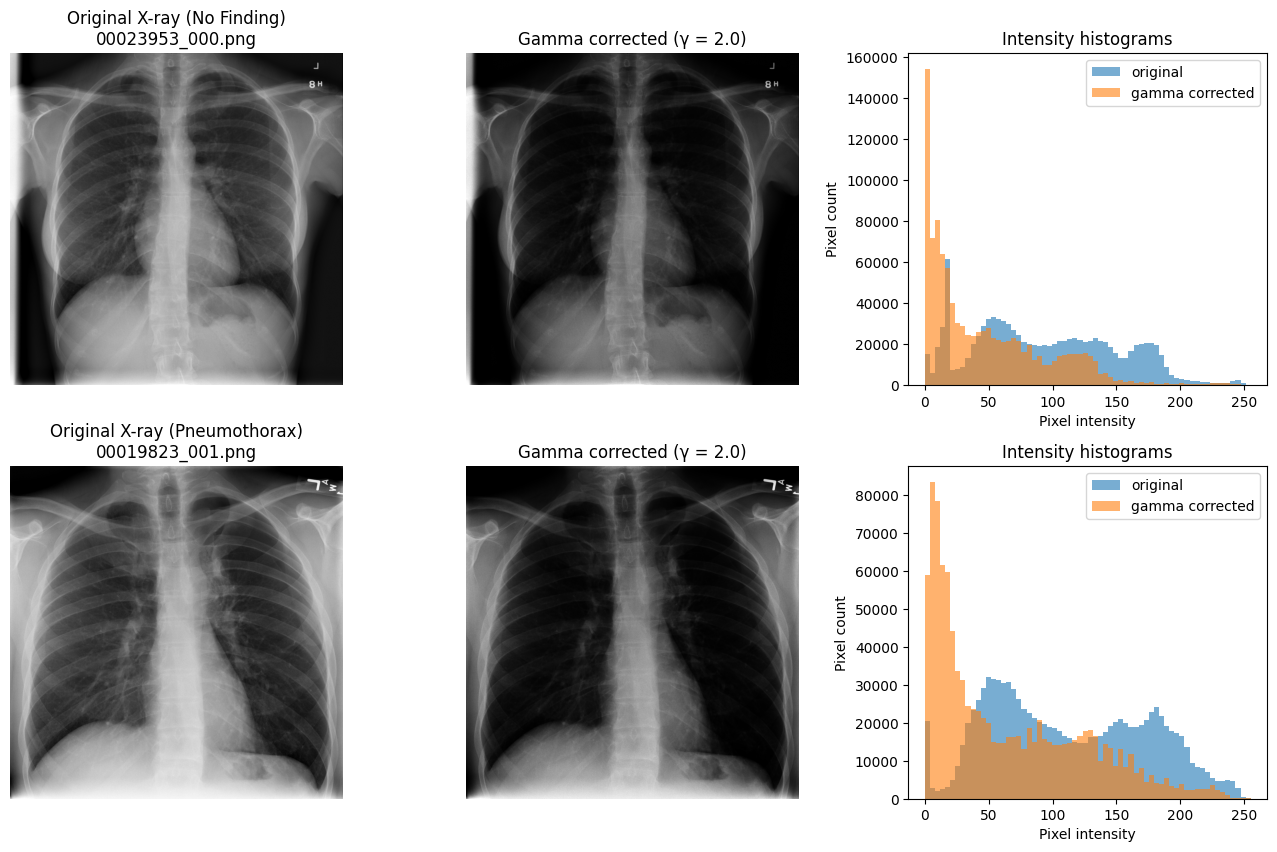

In [5]:
def visualize_gamma(rep=REP, gamma=2.0):
    fig, axes = plt.subplots(len(rep), 3, figsize=(13, 4.3 * len(rep)))
    for r, (cls, name) in enumerate(rep.items()):
        raw = load_gray(os.path.join(IMG_DIR, name)); gam = gamma_correction(raw, gamma)
        axes[r, 0].imshow(raw, cmap="gray", vmin=0, vmax=255); axes[r, 0].set_title(f"Original X-ray ({cls})\n{name}"); axes[r, 0].axis("off")
        axes[r, 1].imshow(gam, cmap="gray", vmin=0, vmax=255); axes[r, 1].set_title(f"Gamma corrected (γ = {gamma})"); axes[r, 1].axis("off")
        axes[r, 2].hist(raw.ravel(), bins=64, range=(0, 255), alpha=0.6, label="original")
        axes[r, 2].hist(gam.ravel(), bins=64, range=(0, 255), alpha=0.6, label="gamma corrected")
        axes[r, 2].set_title("Intensity histograms"); axes[r, 2].set_xlabel("Pixel intensity"); axes[r, 2].set_ylabel("Pixel count"); axes[r, 2].legend()
    plt.tight_layout(); plt.show()
visualize_gamma()

## 3b. Baseline ROI — Version 1 (preserved)
**v1a — fixed anatomical ROI (two ellipses)** is a coarse, deterministic approximation of where the lungs sit.
**v1b — Otsu-refined ROI:** Otsu thresholding is run *only within* the ellipse mask, followed by morphological cleanup and keeping components that are at least 15 % of the largest one. This was the final ROI of the original pipeline and is kept **unchanged** so that its results remain the baseline for the comparison in Section 18.

In [6]:
def create_lung_roi(image_shape):
    """v1: fixed bilateral elliptical ROI approximation."""
    h, w = image_shape
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.ellipse(mask, center=(int(0.31*w), int(0.52*h)), axes=(int(0.20*w), int(0.34*h)),
                angle=0, startAngle=0, endAngle=360, color=255, thickness=-1)
    cv2.ellipse(mask, center=(int(0.69*w), int(0.52*h)), axes=(int(0.20*w), int(0.34*h)),
                angle=0, startAngle=0, endAngle=360, color=255, thickness=-1)
    return mask

def refine_roi_otsu(image_gamma_u8, ellipse_mask, min_area_ratio=0.15):
    """v1b: Otsu thresholding constrained to the v1 ellipse, then morphological
    cleanup, keeping only components at least min_area_ratio of the largest
    (drops small stray blobs while tolerating asymmetric left/right lung sizes).
    Falls back to the plain ellipse if Otsu finds nothing usable."""
    roi_pixels = image_gamma_u8[ellipse_mask > 0]
    thresh_val = threshold_otsu(roi_pixels)

    otsu_mask = np.zeros_like(ellipse_mask)
    otsu_mask[(image_gamma_u8 < thresh_val) & (ellipse_mask > 0)] = 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    cleaned = cv2.morphologyEx(otsu_mask, cv2.MORPH_CLOSE, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel)

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(cleaned, connectivity=8)
    if n_labels <= 1:
        return ellipse_mask.copy()

    areas = stats[1:, cv2.CC_STAT_AREA]
    max_area = areas.max()
    keep_labels = [i + 1 for i, a in enumerate(areas) if a >= min_area_ratio * max_area]
    final_mask = np.isin(labels, keep_labels).astype(np.uint8) * 255
    return final_mask

def split_roi_at_midline(roi_mask):
    """Version 1 left/right split: image midline (column w//2)."""
    h, w = roi_mask.shape
    left_mask = np.zeros((h, w), dtype=np.uint8); right_mask = np.zeros((h, w), dtype=np.uint8)
    left_mask[:, :w//2] = roi_mask[:, :w//2]; right_mask[:, w//2:] = roi_mask[:, w//2:]
    return left_mask, right_mask

# Preview coverage on the sample image
ellipse_mask = create_lung_roi(sample_img.shape)
refined_mask = refine_roi_otsu(sample_img, ellipse_mask)
print("Ellipse coverage: %.2f%%" % ((ellipse_mask>0).sum()/ellipse_mask.size*100))
print("Refined coverage: %.2f%%" % ((refined_mask>0).sum()/refined_mask.size*100))
print("Refined stays within ellipse: %.1f%%" % (
    ((refined_mask>0)&(ellipse_mask>0)).sum()/(refined_mask>0).sum()*100))

Ellipse coverage: 42.38%
Refined coverage: 18.45%
Refined stays within ellipse: 100.0%


## 4. Lung Segmentation — Version 2 (classical, Chan et al. 2018 inspired)
The fixed ellipse only *approximates* where the lungs are. Version 2 segments the lung fields from the image itself using classical image processing only.

**Method implemented in `segment_lungs(image)`**

1. **Gamma-corrected image** (γ = 2.0), lightly Gaussian-smoothed (σ = 4 px) to suppress rib/vessel texture.
2. **Air removal (safeguard):** very dark pixels (< 10) connected to the image border are the air outside the body; they are excluded so they cannot bias the threshold or merge with the lungs.
3. **Otsu thresholding** on the remaining body pixels → dark class (lungs + other dark tissue). Otsu is then applied **a second time inside the dark class** to obtain the *lung core*. (On NIH images a single global Otsu leaves the lungs merged with neck/shoulder/abdomen — checked visually — so the recursive Otsu is used.)
4. **Hole filling:** small closing (7 px) + filling of interior holes (ribs, vessels, ECG leads). Only holes smaller than 1 % of the image are filled; unrestricted filling would fill the whole body when dark air surrounds it.
5. **8-connected component analysis** of the binary image (after a multi-scale morphological opening that cuts thin bridges to neck/shoulders/abdomen).
6. **Lung-candidate identification with anatomical checks:** area of one lung between 1.5 % and 30 % of the image; centroid inside a central window; minimum height/width; limited contact with the top/left/right image border; solidity ≥ 0.72 (compact shape).
7. **Selection of the two lung components:** one candidate on the image-left side and one on the image-right side (opposite sides of the chest), similar area (ratio ≥ 0.15), overlapping vertically; the pair with the largest combined area / most compact scale is kept.
8. **Constrained growing + final hole filling / cleanup:** each selected core is grown by ≤ 15 px back into the looser Otsu binary (recovers the lung border), thin protrusions and image-border strips are removed, holes are filled.
9. **Segmentation status:** the mask is accepted only if a plausible left + right pair is found and both final lungs are compact; otherwise `success = False` with a reason (no substitute mask is created).

Returns `lung_mask, segmented_image, info` where `info` also contains the intermediate binaries, the separate left/right masks and `success` / `reason`.
"Left"/"right" always means the **left/right side of the image** (the patient's right/left lung), the same convention as Version 1.

In [7]:
SEG_CFG = dict(
    air_thresh=10, blur_sigma=4, close_k=7, max_hole_frac=0.01,
    core_levels=('low', 'mid', 'otsu', 'vlow'),       # tried in this order until a valid lung pair is found
    open_scales=(3, 9, 15, 21, 31, 41, 51, 61),
    grow_radius=15, final_open_k=41, border_margin_frac=0.03, min_final_solidity=0.78,
    min_comp_frac=0.015, max_comp_frac=0.30,          # area of ONE lung / image area
    cx_range=(0.10, 0.90), cy_range=(0.20, 0.70),     # centroid window (fractions of W, H)
    min_h_frac=0.20, min_w_frac=0.06,                 # bounding-box extent
    max_border_contact=0.30, min_solidity=0.72,
    min_pair_area_ratio=0.15, min_area_keep=0.70, total_frac_range=(0.04, 0.55), min_vertical_overlap=0.30,
)

def _ell(k): return cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
def _label8(b): return ndi.label(b, structure=np.ones((3, 3), int))

def outside_air(g, thr):
    """Very dark pixels connected to the image border = air outside the body."""
    lab, _ = _label8(g < thr)
    b = np.unique(np.concatenate([lab[0], lab[-1], lab[:, 0], lab[:, -1]])); b = b[b > 0]
    return np.isin(lab, b)

def fill_small_holes(binary, max_hole_frac):
    """Hole filling restricted to holes smaller than max_hole_frac of the image (unrestricted filling
    would also fill the whole bright body whenever dark outside-air wraps around it)."""
    holes = ndi.binary_fill_holes(binary) & ~binary
    lab, n = ndi.label(holes)
    if n == 0: return binary
    areas = ndi.sum(holes, lab, range(1, n + 1))
    return binary | np.isin(lab, 1 + np.nonzero(areas <= max_hole_frac * binary.size)[0])

def lung_candidates(binary, cfg):
    """8-connected components that satisfy basic anatomical plausibility checks."""
    H, W = binary.shape
    lab, n = _label8(binary); cands = []
    for i, sl in enumerate(ndi.find_objects(lab), 1):
        comp = lab[sl] == i
        area = int(comp.sum()); frac = area / (H * W)
        if not (cfg['min_comp_frac'] <= frac <= cfg['max_comp_frac']): continue
        ys, xs = np.nonzero(comp); cy = ys.mean() + sl[0].start; cx = xs.mean() + sl[1].start
        if not (cfg['cx_range'][0] * W <= cx <= cfg['cx_range'][1] * W): continue
        if not (cfg['cy_range'][0] * H <= cy <= cfg['cy_range'][1] * H): continue
        bh, bw = comp.shape
        if bh < cfg['min_h_frac'] * H or bw < cfg['min_w_frac'] * W: continue
        contact = (comp[0, :].sum() if sl[0].start == 0 else 0) + \
                  (comp[:, 0].sum() if sl[1].start == 0 else 0) + \
                  (comp[:, -1].sum() if sl[1].stop == W else 0)          # bottom edge allowed
        if contact > cfg['max_border_contact'] * max(bh, bw): continue
        solidity = area / max(cv2.contourArea(cv2.convexHull(cv2.findNonZero(comp.astype(np.uint8)))), 1.0)
        if solidity < cfg['min_solidity']: continue
        cands.append(dict(label=i, area=area, cx=cx, cy=cy, solidity=solidity,
                          bbox=(sl[0].start, sl[0].stop, sl[1].start, sl[1].stop)))
    return lab, cands

def pick_lung_pair(cands, W, H, cfg):
    """One candidate on each side of the chest (image-left / image-right); best = largest combined area."""
    best = None
    for l in [c for c in cands if c['cx'] < W / 2]:
        for r in [c for c in cands if c['cx'] >= W / 2]:
            if min(l['area'], r['area']) / max(l['area'], r['area']) < cfg['min_pair_area_ratio']: continue
            if not (cfg['total_frac_range'][0] <= (l['area'] + r['area']) / (H * W) <= cfg['total_frac_range'][1]): continue
            ov = min(l['bbox'][1], r['bbox'][1]) - max(l['bbox'][0], r['bbox'][0])
            if ov < cfg['min_vertical_overlap'] * min(l['bbox'][1] - l['bbox'][0], r['bbox'][1] - r['bbox'][0]): continue
            sc = l['area'] + r['area']
            if best is None or sc > best[0]: best = (sc, l, r)
    return None if best is None else (best[1], best[2])

In [8]:
def segment_lungs(img_gamma_u8, cfg=SEG_CFG):
    """Classical lung segmentation inspired by Chan et al. (2018); no learning involved.
    Returns (lung_mask uint8 0/255, segmented_image, info). info holds the intermediate stages,
    the left/right lung masks, and `success` / `reason` (segmentation status)."""
    g = img_gamma_u8; H, W = g.shape
    air = outside_air(g, cfg['air_thresh'])
    gb = cv2.GaussianBlur(g, (0, 0), cfg['blur_sigma'])
    t = threshold_otsu(gb[~air])                                  # (1) Otsu over body pixels
    otsu_bin = (gb < t) & ~air                                    #     lungs + other dark tissue
    t_low = threshold_otsu(gb[otsu_bin])                          #     second Otsu inside the dark class
    levels = dict(low=t_low, mid=(t_low + t) / 2, otsu=t, vlow=0.75 * t_low)
    info = dict(otsu_thresh=int(t), otsu_low_thresh=int(t_low), air=air, otsu_binary=otsu_bin,
                success=False, reason='no plausible left/right lung pair found', core_level=None, open_scale=None,
                left_mask=np.zeros((H, W), np.uint8), right_mask=np.zeros((H, W), np.uint8))
    pair = None
    for lvl in cfg['core_levels']:
        core = (gb < levels[lvl]) & ~air
        closed = cv2.morphologyEx(core.astype(np.uint8), cv2.MORPH_CLOSE, _ell(cfg['close_k'])).astype(bool)
        filled = fill_small_holes(closed, cfg['max_hole_frac'])    # (2) hole filling
        options = []
        for k in cfg['open_scales']:                               # (3) 8-connected components (multi-scale opening
            cand_bin = cv2.morphologyEx(filled.astype(np.uint8), cv2.MORPH_OPEN, _ell(k)).astype(bool)  # cuts bridges)
            lab_k, cands = lung_candidates(cand_bin, cfg)          # (4) lung candidates
            p = pick_lung_pair(cands, W, H, cfg)                   # (5) two lung components
            if p is not None: options.append((k, lab_k, p))
        if options:
            # among valid scales keep the most compact pair (mean solidity) whose area is >= 70% of the largest pair
            best_area = max(p[0]['area'] + p[1]['area'] for _, _, p in options)
            ok_opts = [o for o in options if o[2][0]['area'] + o[2][1]['area'] >= cfg['min_area_keep'] * best_area]
            k, lab, pair = max(ok_opts, key=lambda o: o[2][0]['solidity'] + o[2][1]['solidity'])
            info.update(core_level=lvl, open_scale=k, filled_binary=filled, core_binary=core)
        if pair is not None: break
    if pair is None:
        info.update(filled_binary=filled, core_binary=core)
        return np.zeros((H, W), np.uint8), np.zeros_like(g), info
    allowed = otsu_bin | filled
    masks = []
    for c in pair:
        m = lab == c['label']
        m = cv2.dilate(m.astype(np.uint8), _ell(2 * cfg['grow_radius'] + 1)).astype(bool) & allowed   # constrained growing
        l2, _ = _label8(m); seed = l2[lab == c['label']]; m = l2 == np.bincount(seed[seed > 0]).argmax()
        b = int(cfg['border_margin_frac'] * H)                     # lungs never reach the top/side image edges
        m[:b, :] = False; m[:, :b] = False; m[:, W - b:] = False
        m2 = cv2.morphologyEx(m.astype(np.uint8), cv2.MORPH_OPEN, _ell(cfg['final_open_k'])).astype(bool)
        l3, _ = _label8(m2); seed3 = l3[lab == c['label']]
        if (seed3 > 0).any(): m = l3 == np.bincount(seed3[seed3 > 0]).argmax()
        m = fill_small_holes(cv2.morphologyEx(m.astype(np.uint8), cv2.MORPH_CLOSE, _ell(15)).astype(bool), 0.02)  # (6) final fill
        masks.append(m)
    left, right = masks; right = right & ~left
    for nm, m in (('left', left), ('right', right)):
        if m.sum() == 0: info['reason'] = f'{nm} lung empty after cleanup'; return np.zeros((H, W), np.uint8), np.zeros_like(g), info
        sol = m.sum() / max(cv2.contourArea(cv2.convexHull(cv2.findNonZero(m.astype(np.uint8)))), 1.0)
        if sol < cfg['min_final_solidity']:
            info['reason'] = f'{nm} lung implausible shape (solidity {sol:.2f})'
            return np.zeros((H, W), np.uint8), np.zeros_like(g), info
    mask = (left | right).astype(np.uint8) * 255
    info.update(success=True, reason='ok', left_mask=left.astype(np.uint8) * 255, right_mask=right.astype(np.uint8) * 255,
                left_area=int(left.sum()), right_area=int(right.sum()))
    return mask, np.where(mask > 0, g, 0).astype(np.uint8), info

## 5. Segmentation Visualization
Representative images (one Pneumothorax, one No Finding) shown stage by stage, then a before / mask / after view, then a comparison with the Version 1 elliptical ROI. Only representative images are plotted — all 500 are processed numerically in Section 10.

=== No Finding: 00023953_000.png


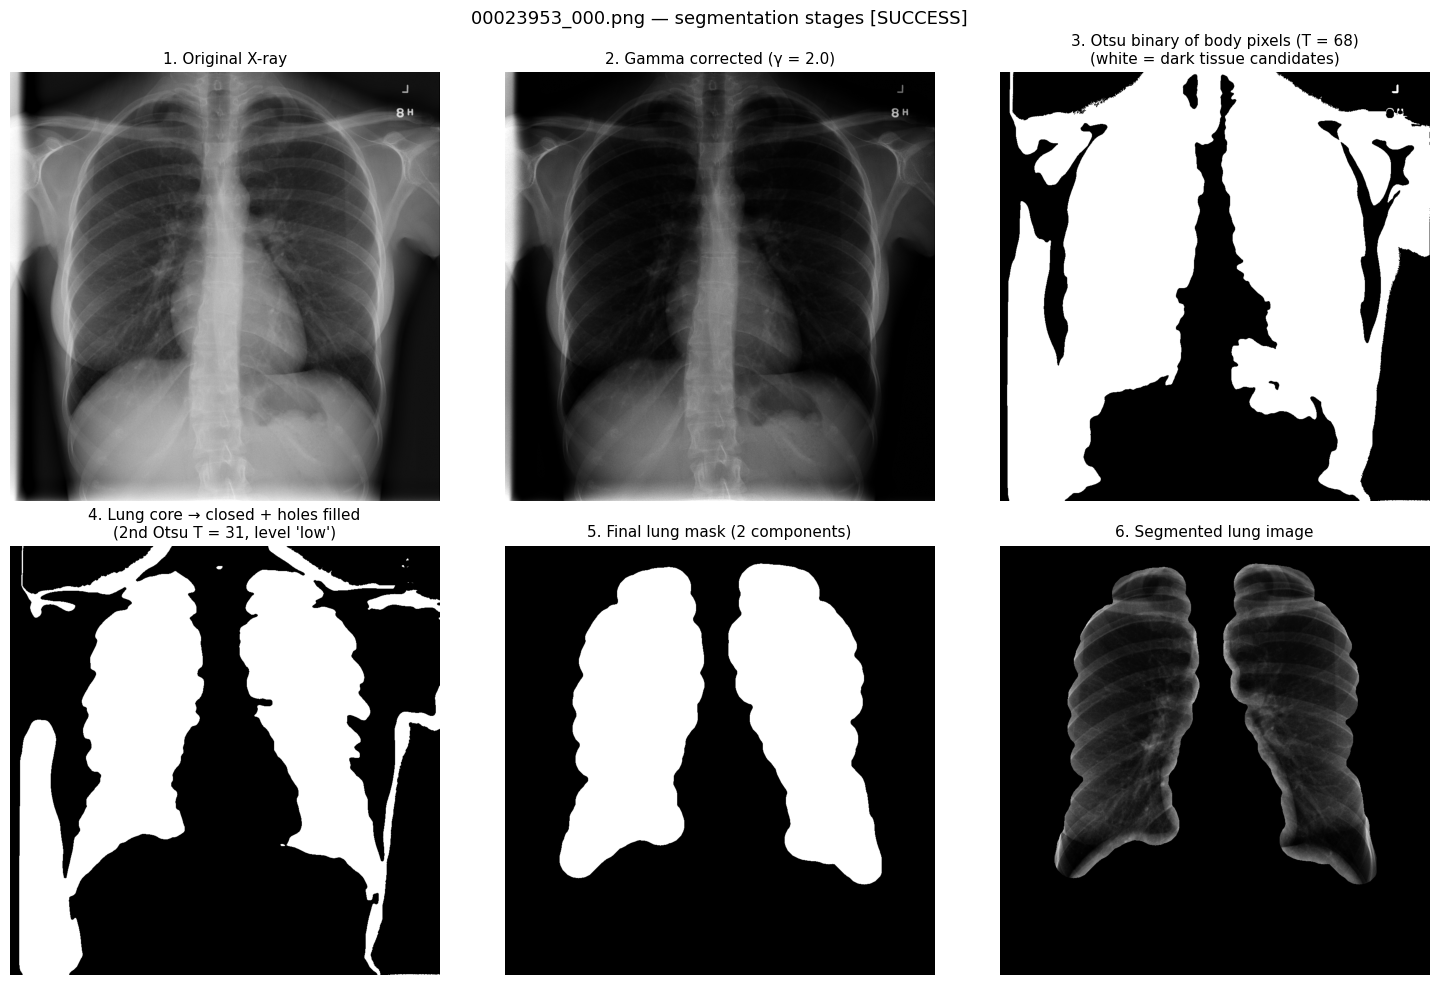

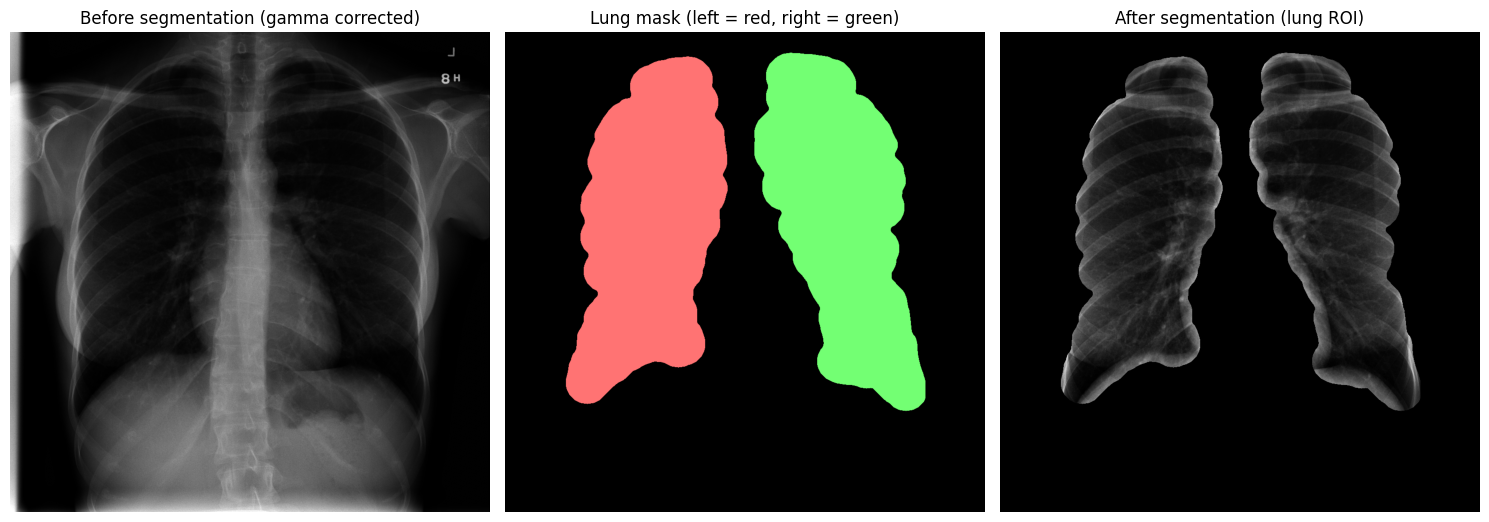

=== Pneumothorax: 00019823_001.png


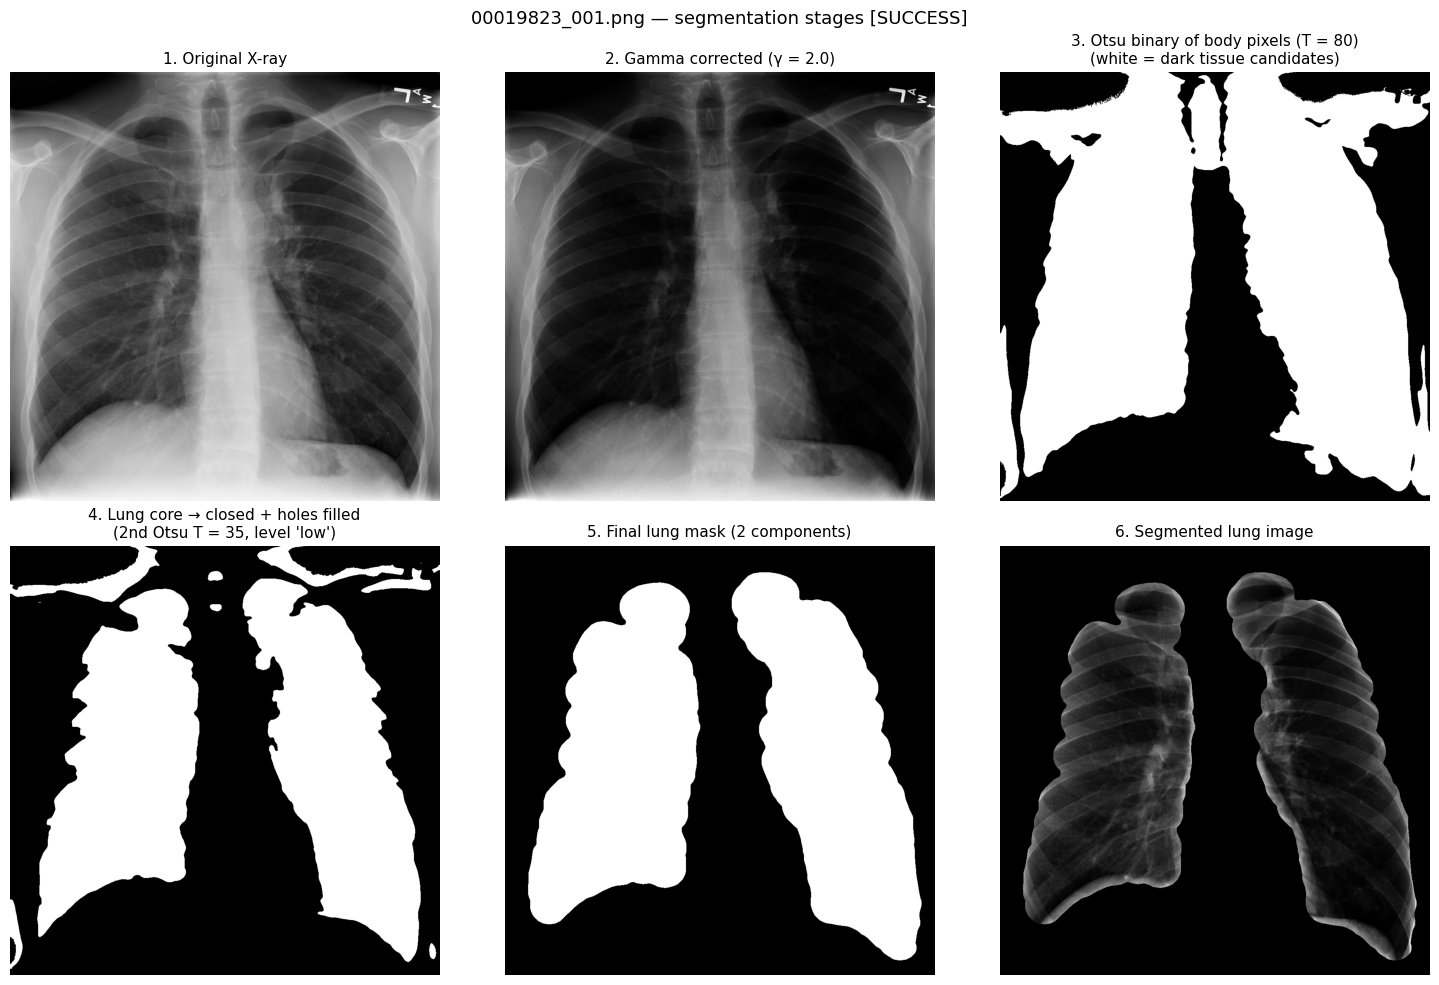

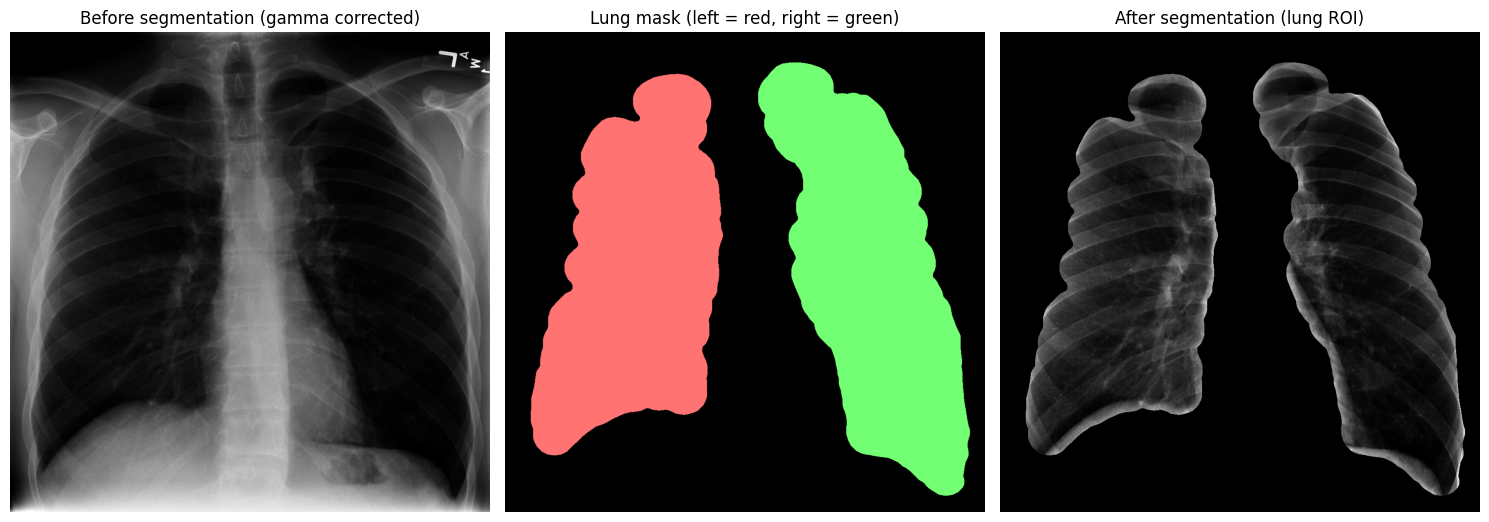

In [9]:
def lung_contours_overlay(gray_u8, info):
    rgb = cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2RGB)
    for m, col in ((info["left_mask"], (255, 0, 0)), (info["right_mask"], (0, 255, 0))):
        cnt, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(rgb, cnt, -1, col, 4)
    return rgb

def visualize_segmentation(image_name):
    raw = load_gray(os.path.join(IMG_DIR, image_name)); g = gamma_correction(raw)
    mask, seg, info = segment_lungs(g)
    status = "SUCCESS" if info["success"] else "FAILED: " + info["reason"]
    # (a) all processing stages
    fig, ax = plt.subplots(2, 3, figsize=(15, 10))
    ax = ax.ravel()
    panels = [(raw, "1. Original X-ray"), (g, "2. Gamma corrected (γ = 2.0)"),
              (info["otsu_binary"], f"3. Otsu binary of body pixels (T = {info['otsu_thresh']})\n(white = dark tissue candidates)"),
              (info["filled_binary"], f"4. Lung core → closed + holes filled\n(2nd Otsu T = {info['otsu_low_thresh']}, level '{info['core_level']}')"),
              (mask, "5. Final lung mask (2 components)"), (seg, "6. Segmented lung image")]
    for a, (im, t) in zip(ax, panels):
        a.imshow(im, cmap="gray"); a.set_title(t, fontsize=11); a.axis("off")
    plt.suptitle(f"{image_name} — segmentation stages [{status}]", fontsize=13)
    plt.tight_layout(); plt.show()
    # (b) before / mask / after
    fig, ax = plt.subplots(1, 3, figsize=(15, 5.2))
    ax[0].imshow(g, cmap="gray"); ax[0].set_title("Before segmentation (gamma corrected)")
    ax[1].imshow(mask, cmap="gray"); ax[1].set_title("Lung mask (left = red, right = green)")
    ax[2].imshow(seg, cmap="gray"); ax[2].set_title("After segmentation (lung ROI)")
    if info["success"]:
        ax[1].imshow(np.dstack([info["left_mask"], info["right_mask"], np.zeros_like(mask)]), alpha=0.55)
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()
    return info

for cls, name in REP.items():
    print(f"=== {cls}: {name}")
    rep_info = visualize_segmentation(name)
    assert rep_info["success"], "representative image failed segmentation — pick another with REP_CANDIDATES"

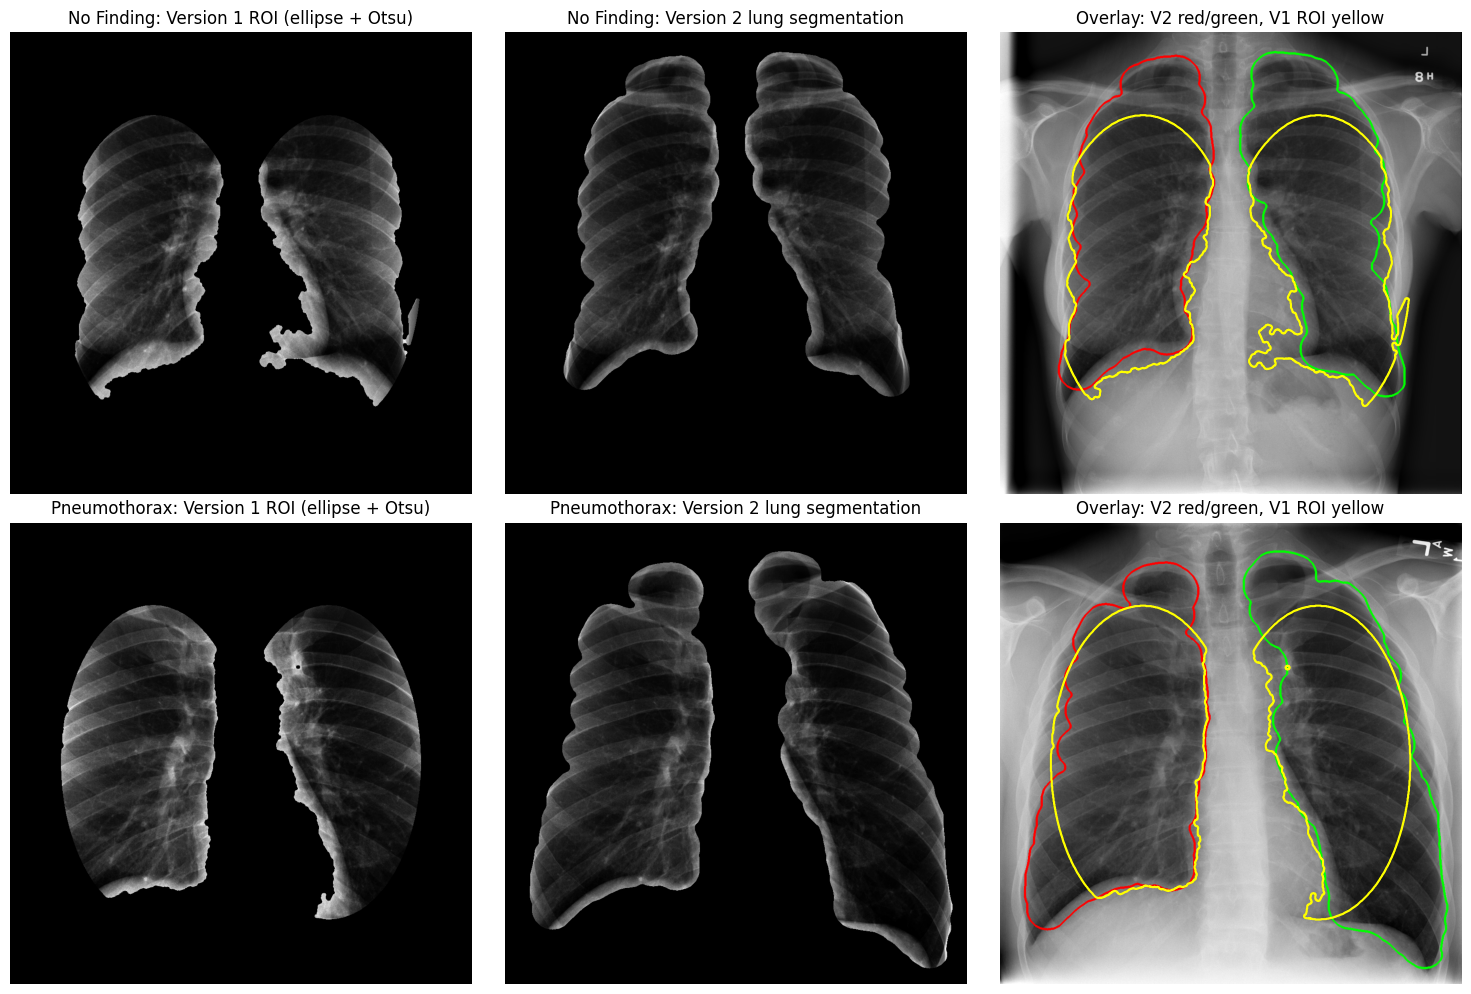

In [10]:
# Version 1 (elliptical ROI) vs Version 2 (lung segmentation) on the representative images
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
for r, (cls, name) in enumerate(REP.items()):
    raw = load_gray(os.path.join(IMG_DIR, name)); g = gamma_correction(raw)
    ell = create_lung_roi(g.shape); v1 = refine_roi_otsu(g, ell); _, _, inf = segment_lungs(g)
    ax[r, 0].imshow(np.where(v1 > 0, g, 0), cmap="gray"); ax[r, 0].set_title(f"{cls}: Version 1 ROI (ellipse + Otsu)")
    ax[r, 1].imshow(np.where(inf["left_mask"] | inf["right_mask"] > 0, g, 0), cmap="gray"); ax[r, 1].set_title(f"{cls}: Version 2 lung segmentation")
    ax[r, 2].imshow(lung_contours_overlay(raw, inf)); ax[r, 2].contour(v1 > 0, levels=[0.5], colors="yellow", linewidths=1.5)
    ax[r, 2].set_title("Overlay: V2 red/green, V1 ROI yellow")
    for a in ax[r]: a.axis("off")
plt.tight_layout(); plt.show()

### 5.1 Visual quality check on a random sample
The segmentation is **not** assumed to be correct: 24 random images (fixed seed) with the accepted lung contours overlaid (left = red, right = green). Failed images (if any in the sample) are shown without a mask and titled with the failure reason.

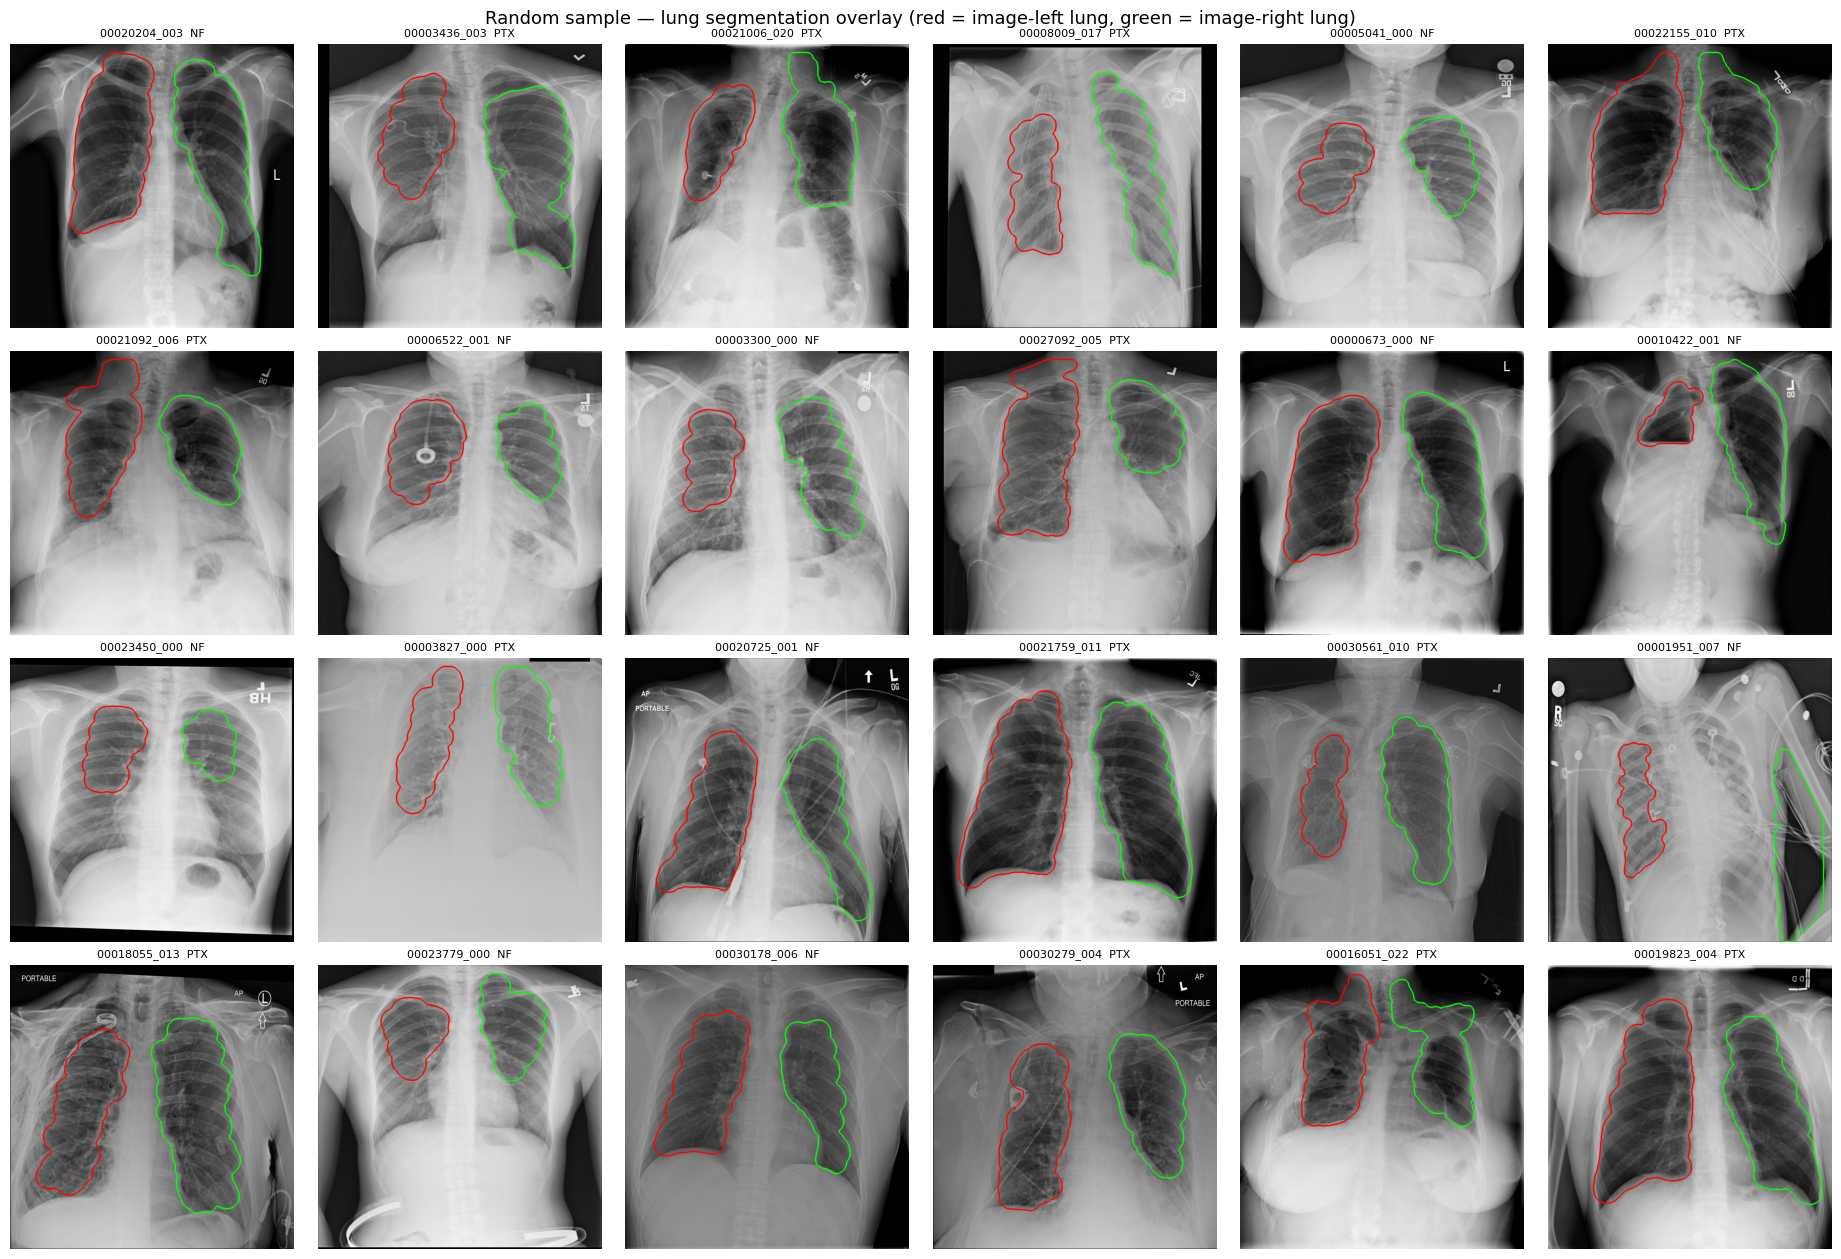

In [11]:
def segmentation_gallery(names, ncols=6, title=None):
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.1 * ncols, 3.2 * nrows)); axes = np.array(axes).ravel()
    for a in axes: a.axis("off")
    for a, name in zip(axes, names):
        raw = load_gray(os.path.join(IMG_DIR, name)); _, _, inf = segment_lungs(gamma_correction(raw))
        lab = int(df.loc[df["Image Index"] == name, "Label"].iloc[0])
        a.imshow(lung_contours_overlay(raw, inf) if inf["success"] else raw, cmap="gray")
        a.set_title(f"{name[:-4]}  {'PTX' if lab else 'NF'}" + ("" if inf["success"] else "\nFAILED: " + textwrap.fill(inf["reason"], 34)),
                    fontsize=8, color="k" if inf["success"] else "r")
    if title: plt.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()

rng = np.random.RandomState(RANDOM_STATE)
gallery_names = list(rng.choice(df["Image Index"].values, size=24, replace=False))
segmentation_gallery(gallery_names, title="Random sample — lung segmentation overlay (red = image-left lung, green = image-right lung)")

## 6. LBP Feature Extraction
Uniform Local Binary Patterns (**P = 8, R = 1**, `method="uniform"` → 10 bins: patterns 0–8 are "uniform", bin 9 collects all non-uniform patterns), unchanged from the original pipeline.
Each pixel is compared with its 8 neighbours to form a binary code that describes the local texture (flat area, edge, corner, spot…). The **normalised histogram** of the codes over the lung pixels is the numerical texture descriptor.

* The LBP map is computed on the gamma-corrected image and **only pixels with `lung_mask > 0` enter the histogram**, so the artificial black background outside the lungs can never dominate it (and no artificial texture is created at the mask boundary).
* Histograms are computed **separately for the left and the right lung** (from the separate lung masks in Version 2, from the image midline split in Version 1), and the **asymmetry** is `|hist_left − hist_right|` per bin.

In [12]:
P, R = 8, 1
n_bins = P + 2

def extract_lbp_features(img_gamma_u8, left_mask, right_mask):
    """Left/right uniform-LBP histograms (only pixels inside the given masks) + absolute asymmetry.
    Returns (left_hist, right_hist, asym, lbp_map), or None if a side has no pixels."""
    lbp = local_binary_pattern(img_gamma_u8, P, R, method="uniform")
    left_lbp, right_lbp = lbp[left_mask > 0], lbp[right_mask > 0]
    if left_lbp.size == 0 or right_lbp.size == 0:
        return None
    left_hist, _ = np.histogram(left_lbp, bins=np.arange(n_bins+1), range=(0, n_bins))
    right_hist, _ = np.histogram(right_lbp, bins=np.arange(n_bins+1), range=(0, n_bins))
    left_hist = left_hist.astype(np.float32); left_hist /= left_hist.sum()
    right_hist = right_hist.astype(np.float32); right_hist /= right_hist.sum()
    asym = np.abs(left_hist - right_hist)
    return left_hist, right_hist, asym, lbp

## 7. LBP Visualization
Left: segmented lung image. Middle: LBP texture map restricted to the lungs (each pixel shows its LBP code). Right: the resulting left- and right-lung LBP histograms — the numbers that become features.

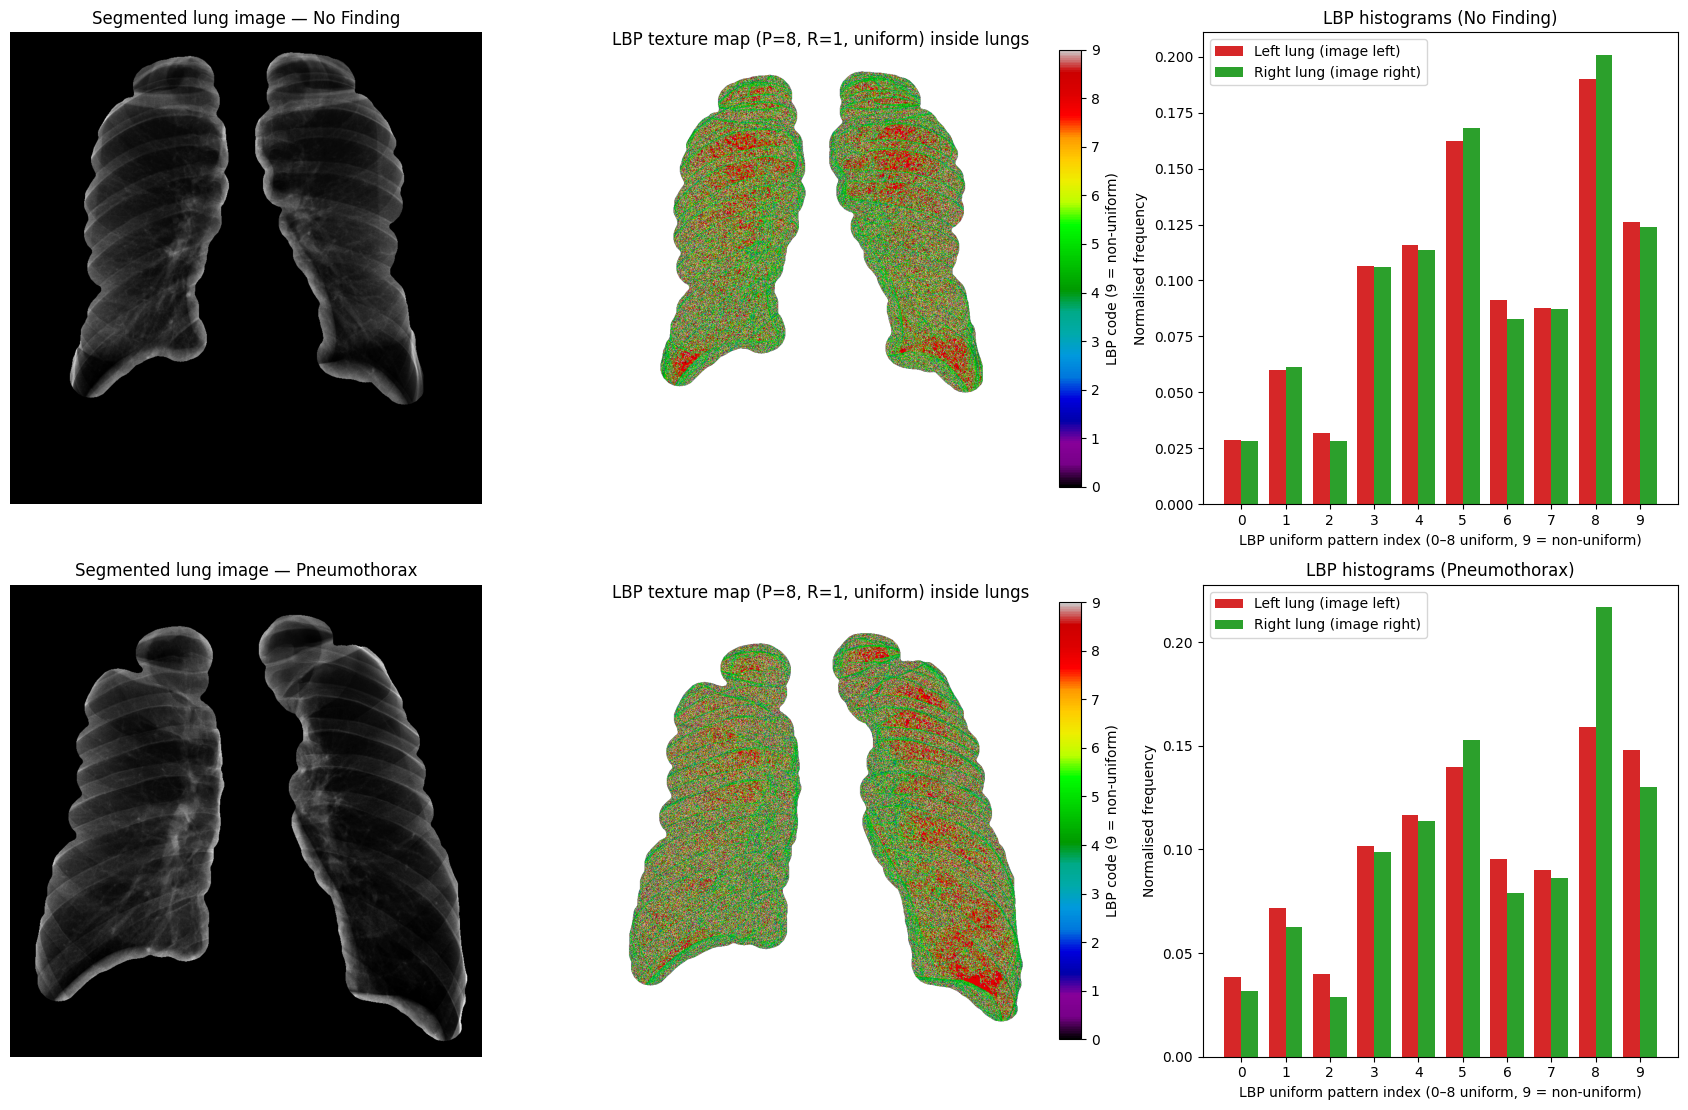

In [13]:
def visualize_lbp(rep=REP):
    fig, axes = plt.subplots(len(rep), 3, figsize=(17, 5.6 * len(rep)))
    for r, (cls, name) in enumerate(rep.items()):
        g = load_and_gamma_correct(os.path.join(IMG_DIR, name)); mask, seg, info = segment_lungs(g)
        lh, rh, asym, lbp = extract_lbp_features(g, info["left_mask"], info["right_mask"])
        axes[r, 0].imshow(seg, cmap="gray"); axes[r, 0].set_title(f"Segmented lung image — {cls}"); axes[r, 0].axis("off")
        im = axes[r, 1].imshow(np.where(mask > 0, lbp, np.nan), cmap="nipy_spectral", vmin=0, vmax=n_bins - 1)
        axes[r, 1].set_title("LBP texture map (P=8, R=1, uniform) inside lungs"); axes[r, 1].axis("off")
        plt.colorbar(im, ax=axes[r, 1], fraction=0.046, label="LBP code (9 = non-uniform)")
        x = np.arange(n_bins); w = 0.38
        axes[r, 2].bar(x - w/2, lh, w, label="Left lung (image left)", color="tab:red")
        axes[r, 2].bar(x + w/2, rh, w, label="Right lung (image right)", color="tab:green")
        axes[r, 2].set_xticks(x); axes[r, 2].set_xlabel("LBP uniform pattern index (0–8 uniform, 9 = non-uniform)")
        axes[r, 2].set_ylabel("Normalised frequency"); axes[r, 2].set_title(f"LBP histograms ({cls})"); axes[r, 2].legend()
    plt.tight_layout(); plt.show()
visualize_lbp()

## 8. Sobel Feature Extraction
The Sobel operator (3×3) gives the horizontal derivative **Sobel X**, the vertical derivative **Sobel Y** and the **gradient magnitude** √(Sx² + Sy²), i.e. edge strength (ribs, vessels, lung/pleural borders, pneumothorax pleural line).

* The derivatives are computed on the gamma-corrected image (real, un-scaled values) and **only pixels with `lung_mask > 0` are used** for the statistics — the zero-valued background outside the lungs is never included (and no artificial edge is created at the mask border).
* Features per lung: mean and standard deviation of the gradient magnitude; asymmetry = absolute left–right difference of each.

In [14]:
def compute_sobel(img_gamma_u8):
    sobel_x = cv2.Sobel(img_gamma_u8, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img_gamma_u8, cv2.CV_64F, 0, 1, ksize=3)
    return sobel_x, sobel_y, np.sqrt(sobel_x**2 + sobel_y**2)

def extract_sobel_features(img_gamma_u8, left_mask, right_mask):
    _, _, sobel_mag = compute_sobel(img_gamma_u8)
    left_sobel, right_sobel = sobel_mag[left_mask > 0], sobel_mag[right_mask > 0]
    lm, rm = left_sobel.mean(), right_sobel.mean()
    ls, rs = left_sobel.std(), right_sobel.std()
    return lm, rm, ls, rs, abs(lm-rm), abs(ls-rs)

## 9. Sobel Visualization
Display scaling only: X/Y responses are shown as signed values and the magnitude is clipped at its 99th percentile inside the lungs so that edges are visible. The feature values themselves use the unscaled numbers.

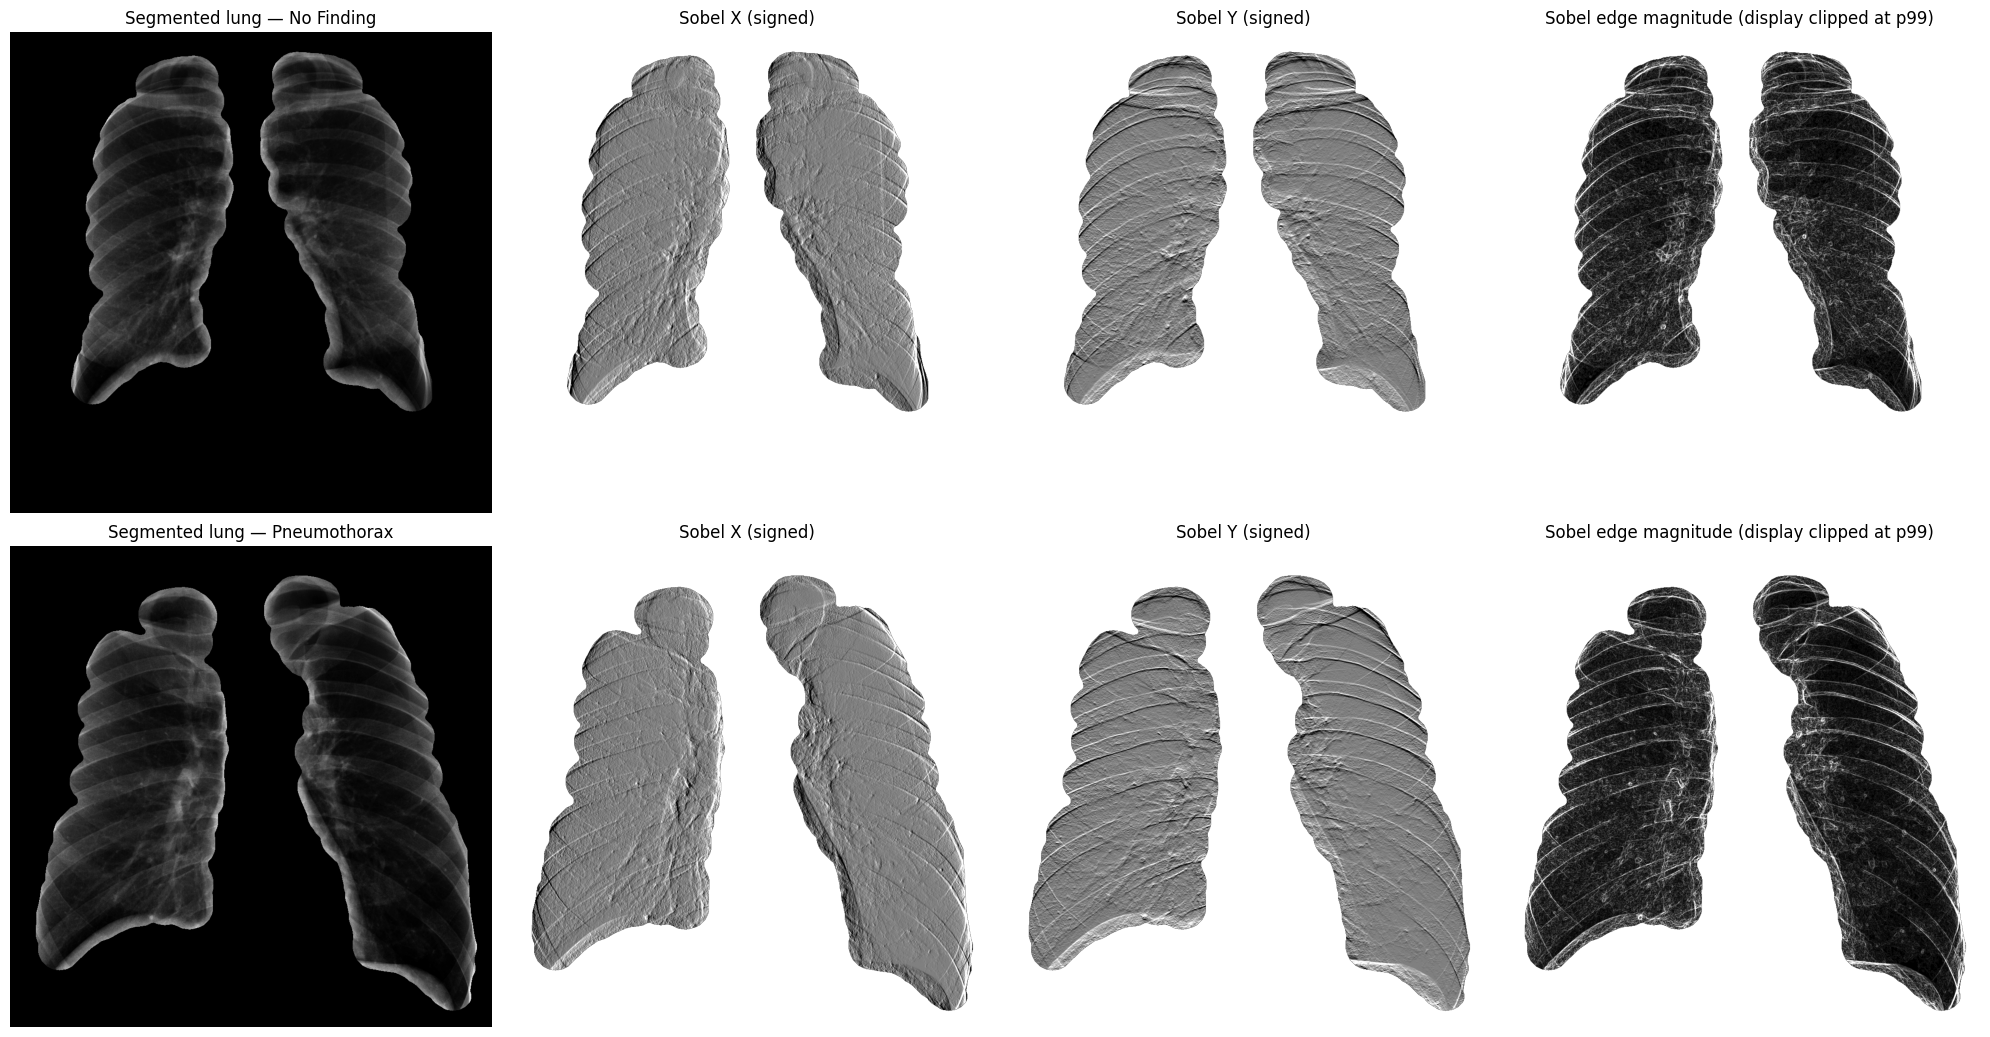

In [15]:
def visualize_sobel(rep=REP):
    fig, axes = plt.subplots(len(rep), 4, figsize=(20, 5.3 * len(rep)))
    for r, (cls, name) in enumerate(rep.items()):
        g = load_and_gamma_correct(os.path.join(IMG_DIR, name)); mask, seg, info = segment_lungs(g)
        sx, sy, mag = compute_sobel(g); inside = mask > 0
        lim = np.percentile(np.abs(np.concatenate([sx[inside], sy[inside]])), 99); vmax = np.percentile(mag[inside], 99)
        axes[r, 0].imshow(seg, cmap="gray"); axes[r, 0].set_title(f"Segmented lung — {cls}")
        axes[r, 1].imshow(np.where(inside, sx, np.nan), cmap="gray", vmin=-lim, vmax=lim); axes[r, 1].set_title("Sobel X (signed)")
        axes[r, 2].imshow(np.where(inside, sy, np.nan), cmap="gray", vmin=-lim, vmax=lim); axes[r, 2].set_title("Sobel Y (signed)")
        axes[r, 3].imshow(np.where(inside, mag, np.nan), cmap="gray", vmin=0, vmax=vmax); axes[r, 3].set_title("Sobel edge magnitude (display clipped at p99)")
        for a in axes[r]: a.axis("off")
    plt.tight_layout(); plt.show()
visualize_sobel()

## 10. Feature Dataset Generation (Version 2)
`extract_all_features` runs the whole chain for one image (grayscale → gamma → lung segmentation → LBP + Sobel + asymmetry). Its output is one row per X-ray; **failed segmentations are kept** (`Segmentation_Success = 0`, reason in `Segmentation_Status`, feature values left empty) — no arbitrary substitute features are created.

The 36-feature design of the original pipeline is preserved (10 LBP bins × {left, right, asymmetry} + 6 Sobel values). Only the column names were made descriptive:

| Old name (v1 notebook) | New name |
|---|---|
| `LBP_L_i` / `LBP_R_i` / `LBP_ASYM_i` (i = 0–9) | `LBP_Left_i` / `LBP_Right_i` / `LBP_Asymmetry_i` |
| `Sobel_L_Mean`, `Sobel_R_Mean` | `Sobel_Left_Mean`, `Sobel_Right_Mean` |
| `Sobel_L_Std`, `Sobel_R_Std` | `Sobel_Left_Std`, `Sobel_Right_Std` |
| `Sobel_Mean_Asym`, `Sobel_Std_Asym` | `Sobel_Asymmetry_Mean`, `Sobel_Asymmetry_Std` |

Meaning is unchanged; only the ROI that the values are computed from differs (Version 2: segmented lungs).

In [16]:
FEATURE_NAMES = ([f"LBP_Left_{i}" for i in range(n_bins)] + [f"LBP_Right_{i}" for i in range(n_bins)]
                 + [f"LBP_Asymmetry_{i}" for i in range(n_bins)]
                 + ["Sobel_Left_Mean", "Sobel_Right_Mean", "Sobel_Left_Std", "Sobel_Right_Std",
                    "Sobel_Asymmetry_Mean", "Sobel_Asymmetry_Std"])
assert len(FEATURE_NAMES) == 36

def extract_all_features(image_name, method="segmentation"):
    """One row of features for one X-ray.
    method = "segmentation"      -> Version 2 (classical lung segmentation)
    method = "ellipse_baseline"  -> Version 1 (elliptical ROI refined by Otsu; original behaviour incl. its fallback)"""
    row = {"Image Index": image_name, "Segmentation_Success": 0, "Segmentation_Status": ""}
    g = load_and_gamma_correct(os.path.join(IMG_DIR, image_name))
    if g is None:
        row["Segmentation_Status"] = "image could not be read"; return row
    if method == "segmentation":
        mask, seg, info = segment_lungs(g)
        if not info["success"]:
            row["Segmentation_Status"] = info["reason"]; return row
        left_mask, right_mask = info["left_mask"], info["right_mask"]
        lbp_result = extract_lbp_features(g, left_mask, right_mask)
        row["Segmentation_Status"] = "ok"
    else:
        ellipse = create_lung_roi(g.shape); roi = refine_roi_otsu(g, ellipse)
        left_mask, right_mask = split_roi_at_midline(roi)
        lbp_result = extract_lbp_features(g, left_mask, right_mask)
        if lbp_result is None:          # original v1 fallback: plain ellipse if a refined half is empty
            left_mask, right_mask = split_roi_at_midline(ellipse)
            lbp_result = extract_lbp_features(g, left_mask, right_mask)
        row["Segmentation_Status"] = "fixed elliptical ROI (no segmentation)"
    left_hist, right_hist, asym, _ = lbp_result
    sobel_feats = extract_sobel_features(g, left_mask, right_mask)
    row.update(dict(zip(FEATURE_NAMES, left_hist.tolist() + right_hist.tolist() + asym.tolist() + list(sobel_feats))))
    row["Segmentation_Success"] = 1
    return row

def build_feature_df(method):
    rows = Parallel(n_jobs=-1)(delayed(extract_all_features)(n, method) for n in df["Image Index"])
    out = df[["Image Index", "Patient ID", "Label"]].merge(pd.DataFrame(rows), on="Image Index", how="left")
    return out[["Image Index", "Patient ID", "Label", "Segmentation_Success", "Segmentation_Status"] + FEATURE_NAMES]

feature_df = build_feature_df("segmentation")
os.makedirs(os.path.dirname(FEATURE_CSV), exist_ok=True)
feature_df.to_csv(FEATURE_CSV, index=False)
print("Saved:", FEATURE_CSV, "| shape:", feature_df.shape)

Saved: ../features/pneumothorax_extracted_features_v2.csv | shape: (500, 41)


## 11. Feature Dataset Validation
Checks on the saved feature table: one row per X-ray, no duplicates, expected labels, numeric features, no NaN/inf among successfully segmented images, patient IDs present and failures identifiable.

In [17]:
def validate_feature_dataframe(fdf, meta_df, feature_names=FEATURE_NAMES):
    ok = fdf["Segmentation_Success"] == 1
    feats = fdf[feature_names]
    summary = {
        "Total images processed": len(fdf),
        "Successful segmentations": int(ok.sum()),
        "Failed segmentations": int((~ok).sum()),
        "Pneumothorax": int((fdf["Label"] == 1).sum()),
        "No Finding": int((fdf["Label"] == 0).sum()),
        "Number of numerical features": len(feature_names),
        "NaN values (successful rows)": int(feats[ok].isna().sum().sum()),
        "Infinite values (successful rows)": int(np.isinf(feats[ok].to_numpy(dtype=float)).sum()),
        "NaN cells in failed rows (expected: no features created)": int(feats[~ok].isna().sum().sum()),
    }
    for k, v in summary.items(): print(f"{k + ':':<58}{v}")
    assert len(fdf) == len(meta_df), "one row per X-ray expected"
    assert fdf["Image Index"].is_unique, "duplicate images"
    assert set(fdf["Image Index"]) == set(meta_df["Image Index"])
    assert fdf["Patient ID"].notna().all(), "missing patient IDs"
    assert summary["Pneumothorax"] == 250 and summary["No Finding"] == 250
    assert all(pd.api.types.is_numeric_dtype(fdf[c]) for c in feature_names), "non-numeric feature column"
    assert summary["NaN values (successful rows)"] == 0 and summary["Infinite values (successful rows)"] == 0
    assert (fdf.loc[~ok, "Segmentation_Status"] != "ok").all() and (fdf.loc[ok, "Segmentation_Status"] != "").all()
    return summary

# Validate what was actually written to disk
feature_df = pd.read_csv(FEATURE_CSV)
display(feature_df.head())
print("shape:", feature_df.shape)
feature_df.info()
val_summary = validate_feature_dataframe(feature_df, df)

,Image Index,Patient ID,Label,Segmentation_Success,Segmentation_Status,LBP_Left_0,LBP_Left_1,LBP_Left_2,LBP_Left_3,LBP_Left_4,...,LBP_Asymmetry_6,LBP_Asymmetry_7,LBP_Asymmetry_8,LBP_Asymmetry_9,Sobel_Left_Mean,Sobel_Right_Mean,Sobel_Left_Std,Sobel_Right_Std,Sobel_Asymmetry_Mean,Sobel_Asymmetry_Std
0,00000038_002.png,38,0,1,ok,0.029754,0.063205,0.036279,0.110335,0.124496,...,0.006933,0.004882,0.011635,0.003107,11.264367,14.764267,8.537259,18.780694,3.499900,10.243435
1,00000272_003.png,272,0,1,ok,0.033290,0.061643,0.039430,0.106933,0.135810,...,0.007012,0.002167,0.000484,0.005452,13.449720,13.477077,12.504812,12.736117,0.027356,0.231305
2,00000391_002.png,391,0,1,ok,0.026153,0.051766,0.047222,0.125282,0.184346,...,0.003996,0.002680,0.000724,0.005789,18.915307,18.444290,14.219279,14.467863,0.471017,0.248584
3,00000393_000.png,393,0,1,ok,0.025335,0.052536,0.046293,0.132872,0.190361,...,0.005152,0.003521,0.006618,0.003609,17.878436,17.627526,12.763871,13.532757,0.250910,0.768886
4,00000404_002.png,404,1,1,ok,0.032275,0.067110,0.043384,0.114692,0.130637,...,0.004357,0.005483,0.021170,0.001972,13.095472,11.367149,8.919908,8.689497,1.728323,0.230411


shape: (500, 41)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 41 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Image Index           500 non-null    object 
 1   Patient ID            500 non-null    int64  
 2   Label                 500 non-null    int64  
 3   Segmentation_Success  500 non-null    int64  
 4   Segmentation_Status   500 non-null    object 
 5   LBP_Left_0            461 non-null    float64
 6   LBP_Left_1            461 non-null    float64
 7   LBP_Left_2            461 non-null    float64
 8   LBP_Left_3            461 non-null    float64
 9   LBP_Left_4            461 non-null    float64
 10  LBP_Left_5            461 non-null    float64
 11  LBP_Left_6            461 non-null    float64
 12  LBP_Left_7            461 non-null    float64
 13  LBP_Left_8            461 non-null    float64
 14  LBP_Left_9            461 non-null    float64
 15  LBP_Ri

### 11.1 Failed segmentations
Failed images are listed and a few are displayed (gamma-corrected image, no mask).

39 failed segmentations ({'No Finding': 22, 'Pneumothorax': 17})
Segmentation_Status
no plausible left/right lung pair found         36
left lung implausible shape (solidity 0.75)      1
left lung implausible shape (solidity 0.76)      1
right lung implausible shape (solidity 0.77)     1


,Image Index,Patient ID,Label,Segmentation_Status
0,00001029_003.png,1029,1,no plausible left/right lung pair found
1,00002437_050.png,2437,0,no plausible left/right lung pair found
2,00002450_000.png,2450,0,no plausible left/right lung pair found
3,00004656_001.png,4656,1,no plausible left/right lung pair found
4,00005069_013.png,5069,0,no plausible left/right lung pair found
5,00005079_009.png,5079,0,no plausible left/right lung pair found
6,00005224_000.png,5224,1,no plausible left/right lung pair found
7,00005254_013.png,5254,0,no plausible left/right lung pair found
8,00006321_002.png,6321,0,no plausible left/right lung pair found
9,00006821_007.png,6821,0,no plausible left/right lung pair found


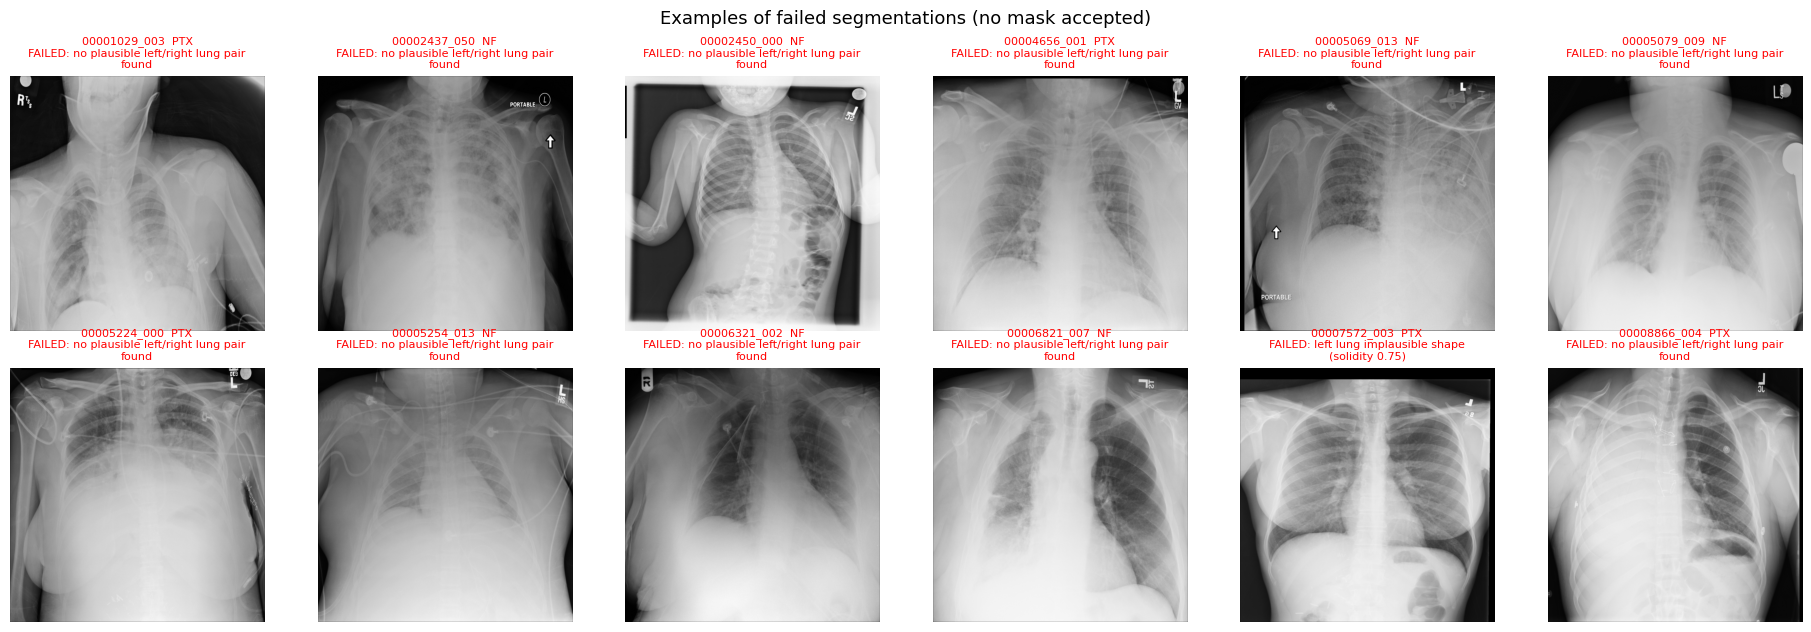

In [18]:
failed_df = feature_df[feature_df["Segmentation_Success"] == 0][["Image Index", "Patient ID", "Label", "Segmentation_Status"]]
print(f"{len(failed_df)} failed segmentations ({failed_df['Label'].map({0: 'No Finding', 1: 'Pneumothorax'}).value_counts().to_dict()})")
print(failed_df["Segmentation_Status"].value_counts().to_string())
display(failed_df.reset_index(drop=True))
if len(failed_df):
    segmentation_gallery(failed_df["Image Index"].tolist()[:12], ncols=6, title="Examples of failed segmentations (no mask accepted)")

## 12. Feature Analysis
Exploratory plots of the saved feature table (successfully segmented images only): class balance, class-wise distributions of a small fixed set of meaningful features, and the left-vs-right relation that motivates the asymmetry features.

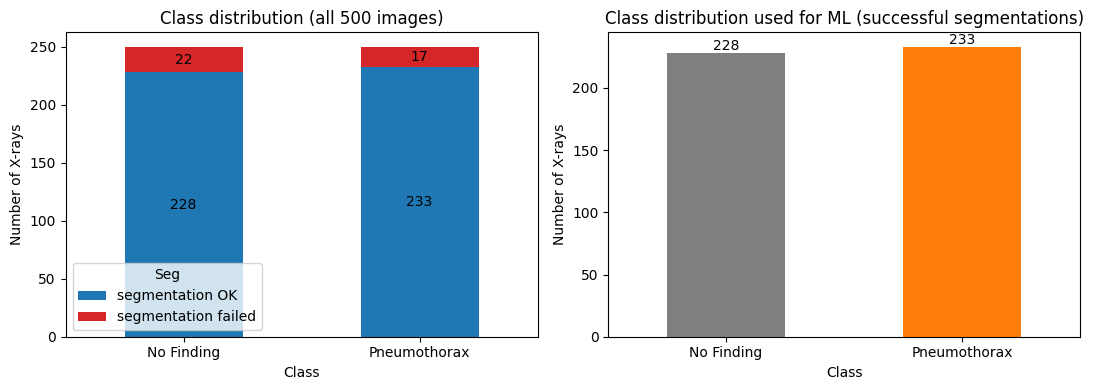

In [19]:
ok_df = feature_df[feature_df["Segmentation_Success"] == 1].copy()
ok_df["Class"] = ok_df["Label"].map({0: "No Finding", 1: "Pneumothorax"})

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts = feature_df.assign(Class=feature_df["Label"].map({0: "No Finding", 1: "Pneumothorax"}),
                           Seg=feature_df["Segmentation_Success"].map({1: "segmentation OK", 0: "segmentation failed"}))
ct = counts.groupby(["Class", "Seg"]).size().unstack(fill_value=0)
ct.plot(kind="bar", stacked=True, ax=ax[0], color=[{"segmentation OK": "tab:blue", "segmentation failed": "tab:red"}[c] for c in ct.columns], rot=0)
ax[0].set_title("Class distribution (all 500 images)"); ax[0].set_ylabel("Number of X-rays"); ax[0].set_xlabel("Class")
for c in ax[0].containers: ax[0].bar_label(c, label_type="center")
ok_df.groupby("Class").size().plot(kind="bar", ax=ax[1], color=["tab:gray", "tab:orange"], rot=0)
ax[1].set_title("Class distribution used for ML (successful segmentations)"); ax[1].set_ylabel("Number of X-rays")
ax[1].bar_label(ax[1].containers[0])
plt.tight_layout(); plt.show()

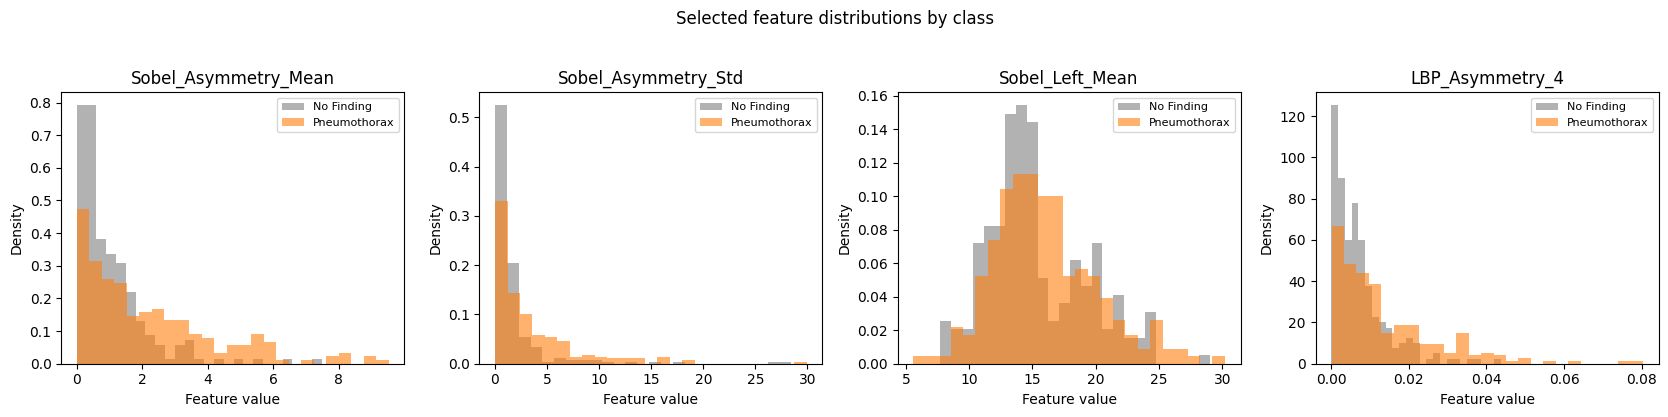

In [20]:
selected = ["Sobel_Asymmetry_Mean", "Sobel_Asymmetry_Std", "Sobel_Left_Mean", "LBP_Asymmetry_4"]
fig, axes = plt.subplots(1, len(selected), figsize=(4.2 * len(selected), 4))
for a, f in zip(axes, selected):
    for cls, colr in (("No Finding", "tab:gray"), ("Pneumothorax", "tab:orange")):
        a.hist(ok_df.loc[ok_df["Class"] == cls, f], bins=25, alpha=0.6, label=cls, color=colr, density=True)
    a.set_title(f); a.set_xlabel("Feature value"); a.set_ylabel("Density"); a.legend(fontsize=8)
plt.suptitle("Selected feature distributions by class", y=1.03); plt.tight_layout(); plt.show()

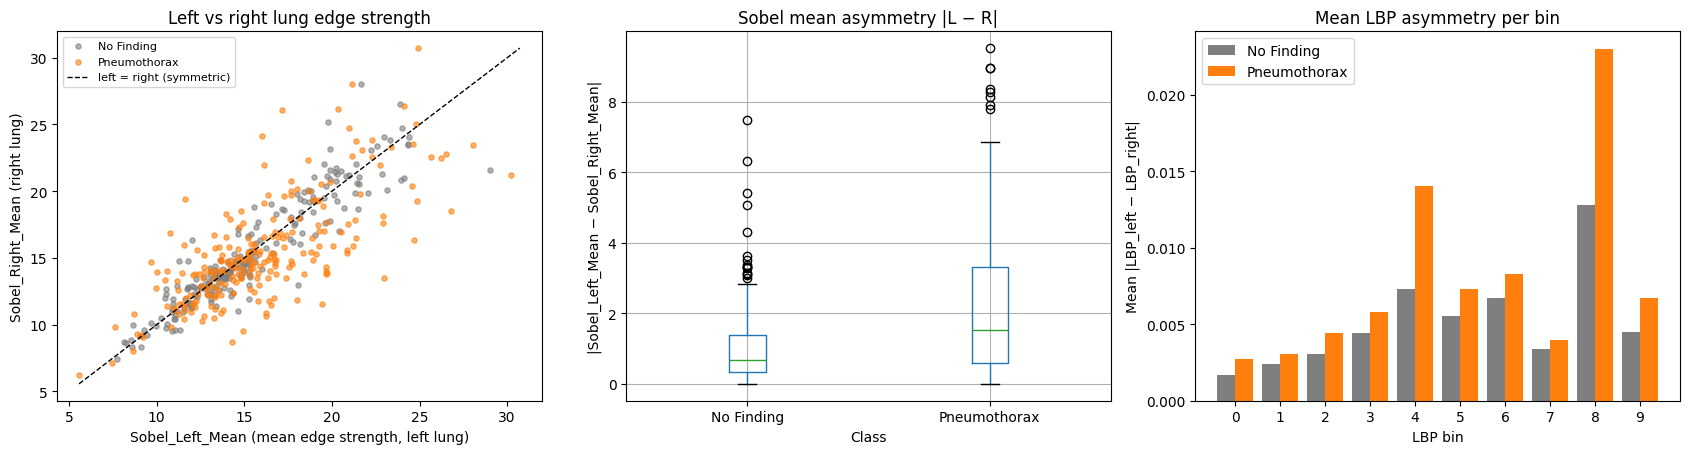

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
for cls, colr in (("No Finding", "tab:gray"), ("Pneumothorax", "tab:orange")):
    s = ok_df[ok_df["Class"] == cls]
    ax[0].scatter(s["Sobel_Left_Mean"], s["Sobel_Right_Mean"], s=14, alpha=0.6, label=cls, color=colr)
lim = [ok_df[["Sobel_Left_Mean", "Sobel_Right_Mean"]].min().min(), ok_df[["Sobel_Left_Mean", "Sobel_Right_Mean"]].max().max()]
ax[0].plot(lim, lim, "k--", lw=1, label="left = right (symmetric)")
ax[0].set_xlabel("Sobel_Left_Mean (mean edge strength, left lung)"); ax[0].set_ylabel("Sobel_Right_Mean (right lung)")
ax[0].set_title("Left vs right lung edge strength"); ax[0].legend(fontsize=8)
ok_df.boxplot(column="Sobel_Asymmetry_Mean", by="Class", ax=ax[1]); ax[1].set_title("Sobel mean asymmetry |L − R|"); ax[1].set_ylabel("|Sobel_Left_Mean − Sobel_Right_Mean|"); ax[1].set_xlabel("Class")
plt.sca(ax[1]); plt.suptitle("")
x = np.arange(n_bins); w = 0.2
for k, (cls, colr) in enumerate((("No Finding", "tab:gray"), ("Pneumothorax", "tab:orange"))):
    s = ok_df[ok_df["Class"] == cls]
    ax[2].bar(x + (k - 0.5) * 0.4, s[[f"LBP_Asymmetry_{i}" for i in range(n_bins)]].mean().values, 0.4, label=cls, color=colr)
ax[2].set_xticks(x); ax[2].set_xlabel("LBP bin"); ax[2].set_ylabel("Mean |LBP_left − LBP_right|"); ax[2].set_title("Mean LBP asymmetry per bin"); ax[2].legend()
plt.tight_layout(); plt.show()

## 13. Patient-wise Train/Test Split
**The ML stage starts from the saved CSV**, not from the in-memory table of the previous section: the file is reloaded and split into metadata columns and feature columns.

Patient-wise 70/30 split (same rule and `random_state = 42` as the original pipeline). **Note on dual-label patients:** 5 patients in this subset have both a `No Finding` and a `Pneumothorax` image (different follow-up visits) — a genuine clinical pattern, not a data error. To keep every image while guaranteeing zero patient leakage, each patient gets a *split-grouping* label with an "any-positive" rule (Pneumothorax if **any** of their images is Pneumothorax). This only decides which side of the split the patient's images land on; image-level labels used for training/evaluation are untouched.

The split is made on all 500 images (exactly as in Version 1) and images whose segmentation failed are dropped **afterwards**, so Version 1 and Version 2 are evaluated on the same patients.

In [22]:
feature_df = pd.read_csv(FEATURE_CSV)          # explicit reload of the intermediate artifact
metadata_cols = ["Image Index", "Patient ID", "Label", "Segmentation_Success", "Segmentation_Status"]
feature_cols = [c for c in feature_df.columns if c not in metadata_cols]
print("Loaded", FEATURE_CSV, feature_df.shape, "->", len(feature_cols), "feature columns")
assert feature_cols == FEATURE_NAMES and all(pd.api.types.is_numeric_dtype(feature_df[c]) for c in feature_cols)

patient_labels = feature_df.groupby("Patient ID")["Label"].max().reset_index()
dual_label_counts = feature_df.groupby("Patient ID")["Label"].nunique()
print("Patients with both Label 0 and Label 1 images:", (dual_label_counts > 1).sum())
print("Patient-level class counts (any-positive rule):"); print(patient_labels["Label"].value_counts())

train_patients, test_patients = train_test_split(
    patient_labels, test_size=0.30, random_state=RANDOM_STATE, stratify=patient_labels["Label"]
)
train_patient_ids = set(train_patients["Patient ID"])
test_patient_ids = set(test_patients["Patient ID"])

train_all = feature_df[feature_df["Patient ID"].isin(train_patient_ids)].copy()
test_all = feature_df[feature_df["Patient ID"].isin(test_patient_ids)].copy()
# images with a failed segmentation are excluded from ML (they have no features); they are reported, not hidden
train_df = train_all[train_all["Segmentation_Success"] == 1].copy()
test_df = test_all[test_all["Segmentation_Success"] == 1].copy()

print("\nTraining patients:", len(train_patient_ids), "| Testing patients:", len(test_patient_ids))
print("Training images: %d (of %d, %d failed segmentation excluded)" % (len(train_df), len(train_all), len(train_all) - len(train_df)))
print("Testing images:  %d (of %d, %d failed segmentation excluded)" % (len(test_df), len(test_all), len(test_all) - len(test_df)))
print("\nTraining class distribution:"); print(train_df["Label"].value_counts())
print("\nTesting class distribution:"); print(test_df["Label"].value_counts())
overlap = set(train_df["Patient ID"]) & set(test_df["Patient ID"])
print("\ntrain patient IDs ∩ test patient IDs =", overlap if overlap else "∅  (patient overlap = 0)")
assert len(train_patient_ids & test_patient_ids) == 0 and len(overlap) == 0, "PATIENT LEAKAGE"
assert set(train_df["Image Index"]).isdisjoint(test_df["Image Index"])

Loaded ../features/pneumothorax_extracted_features_v2.csv (500, 41) -> 36 feature columns
Patients with both Label 0 and Label 1 images: 5
Patient-level class counts (any-positive rule):
Label
0    243
1    206
Name: count, dtype: int64

Training patients: 314 | Testing patients: 135
Training images: 320 (of 342, 22 failed segmentation excluded)
Testing images:  141 (of 158, 17 failed segmentation excluded)

Training class distribution:
Label
0    165
1    155
Name: count, dtype: int64

Testing class distribution:
Label
1    78
0    63
Name: count, dtype: int64

train patient IDs ∩ test patient IDs = ∅  (patient overlap = 0)


## 14. Feature Scaling
`StandardScaler` is **fit on the training data only**, then applied to train and test (no test information leaks into the scaler).

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])
y_train = train_df["Label"].values
y_test = test_df["Label"].values

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Train feature means (should be ~0):", X_train.mean(axis=0)[:3])
print("Train feature stds (should be ~1):", X_train.std(axis=0)[:3])

X_train: (320, 36) | X_test: (141, 36)
Train feature means (should be ~0): [-1.99840144e-16 -7.10542736e-16 -5.27355937e-16]
Train feature stds (should be ~1): [1. 1. 1.]


## 15. SVM Classification
RBF kernel, 5-fold grid search over `C`/`gamma` on the **training data only** (same grid as the original pipeline). The grid deliberately excludes very small `C`/`gamma` combinations, which were found to collapse to a degenerate constant-class predictor on this dataset (verified against a `DummyClassifier` baseline during development). The model is **retrained** on the Version 2 features.

In [24]:
def fit_svm(X, y):
    grid = {"C": [0.5, 1, 5, 10, 50], "gamma": ["scale", "auto", 0.01, 0.05, 0.1], "kernel": ["rbf"]}
    search = GridSearchCV(SVC(class_weight="balanced", probability=True, random_state=RANDOM_STATE),
                          grid, cv=5, scoring="f1", n_jobs=-1)
    return search.fit(X, y)

def fit_rf(X, y):
    grid = {"n_estimators": [100, 200, 300], "max_depth": [None, 5, 10, 15], "min_samples_leaf": [1, 2, 4]}
    search = GridSearchCV(RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
                          grid, cv=5, scoring="f1", n_jobs=-1)
    return search.fit(X, y)

svm_grid = fit_svm(X_train, y_train)
best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test)
y_proba_svm = best_svm.predict_proba(X_test)[:, 1]
print("Best SVM params:", svm_grid.best_params_, "| CV F1: %.4f" % svm_grid.best_score_)
print("Prediction distribution:", np.bincount(y_pred_svm, minlength=2))

Best SVM params: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'} | CV F1: 0.6111
Prediction distribution: [76 65]


c:\Users\Ishit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 16. Random Forest
Same hyper-parameter grid as the original pipeline, 5-fold grid search on the training data only, retrained on the Version 2 features.

In [25]:
rf_grid = fit_rf(X_train, y_train)
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
print("Best RF params:", rf_grid.best_params_, "| CV F1: %.4f" % rf_grid.best_score_)
print("Prediction distribution:", np.bincount(y_pred_rf, minlength=2))

Best RF params: {'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 100} | CV F1: 0.6171
Prediction distribution: [70 71]


## 17. Evaluation (Version 2 — lung segmentation)
Accuracy, precision, recall (sensitivity), F1 and ROC-AUC on the held-out test patients, confusion matrices with TN / FP / FN / TP labelled, and a combined ROC plot.

In [26]:
def evaluate_model(name, y_true, y_pred, y_proba, verbose=True):
    m = {"Model": name, "Accuracy": accuracy_score(y_true, y_pred), "Precision": precision_score(y_true, y_pred, zero_division=0),
         "Recall": recall_score(y_true, y_pred), "F1": f1_score(y_true, y_pred), "ROC-AUC": roc_auc_score(y_true, y_proba)}
    if verbose:
        print(f"--- {name} test-set performance ---")
        for k in ("Accuracy", "Precision", "Recall", "F1", "ROC-AUC"): print(f"{k + ':':<11}{m[k]:.4f}")
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}\n")
        print(classification_report(y_true, y_pred, target_names=["No Finding", "Pneumothorax"], zero_division=0))
    return m

def plot_confusion(ax, y_true, y_pred, title, cmap):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    ax.imshow(cm, cmap=cmap, vmin=0, vmax=cm.max() * 1.25)
    names = [["True Negative (TN)", "False Positive (FP)"], ["False Negative (FN)", "True Positive (TP)"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{names[i][j]}\n{cm[i, j]}", ha="center", va="center", fontsize=12, fontweight="bold")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["No Finding", "Pneumothorax"]); ax.set_yticklabels(["No Finding", "Pneumothorax"])
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label"); ax.set_title(title)

metrics_svm = evaluate_model("SVM (RBF) — V2 segmentation", y_test, y_pred_svm, y_proba_svm)
metrics_rf = evaluate_model("Random Forest — V2 segmentation", y_test, y_pred_rf, y_proba_rf)

--- SVM (RBF) — V2 segmentation test-set performance ---
Accuracy:  0.7234
Precision: 0.8000
Recall:    0.6667
F1:        0.7273
ROC-AUC:   0.7582
TN=50  FP=13  FN=26  TP=52

              precision    recall  f1-score   support

  No Finding       0.66      0.79      0.72        63
Pneumothorax       0.80      0.67      0.73        78

    accuracy                           0.72       141
   macro avg       0.73      0.73      0.72       141
weighted avg       0.74      0.72      0.72       141

--- Random Forest — V2 segmentation test-set performance ---
Accuracy:  0.6950
Precision: 0.7465
Recall:    0.6795
F1:        0.7114
ROC-AUC:   0.7786
TN=45  FP=18  FN=25  TP=53

              precision    recall  f1-score   support

  No Finding       0.64      0.71      0.68        63
Pneumothorax       0.75      0.68      0.71        78

    accuracy                           0.70       141
   macro avg       0.69      0.70      0.69       141
weighted avg       0.70      0.70      0.70    

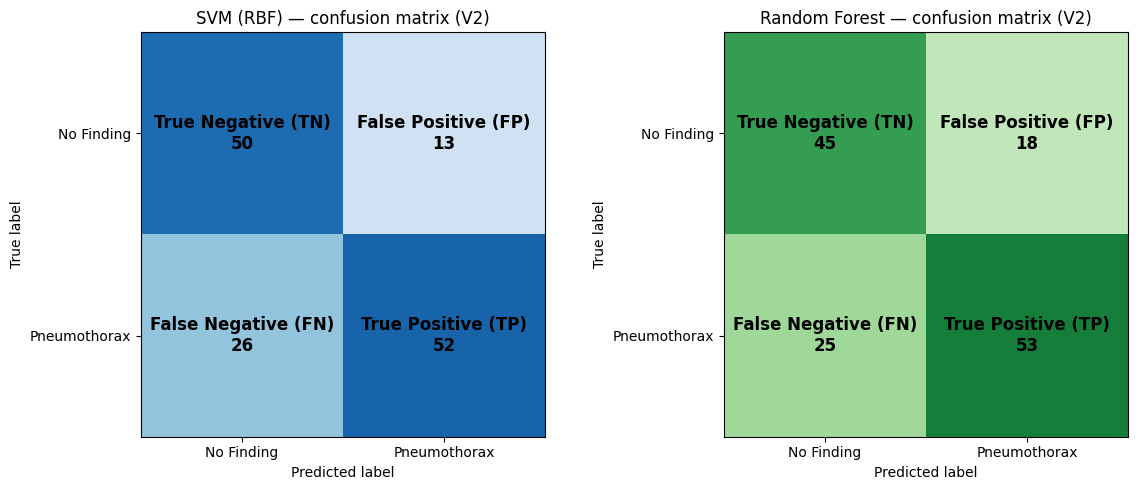

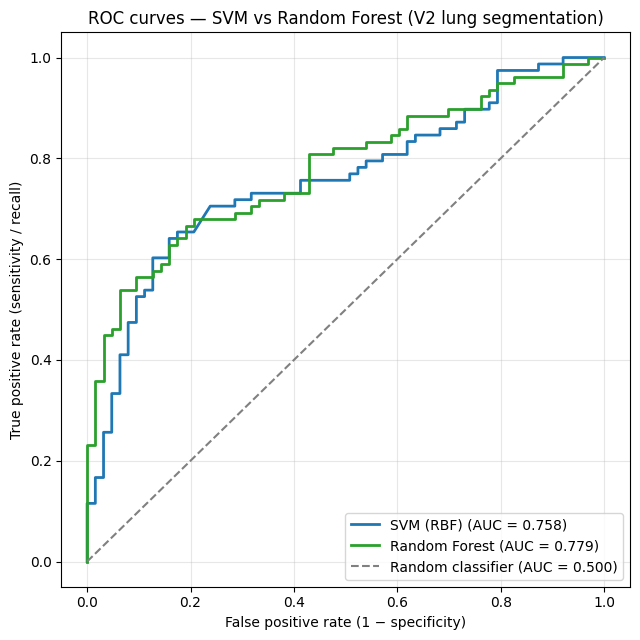

Top 10 most important features (Random Forest, V2):
Sobel_Asymmetry_Mean    0.0839
Sobel_Asymmetry_Std     0.0584
LBP_Asymmetry_8         0.0566
LBP_Asymmetry_4         0.0442
Sobel_Left_Std          0.0415
LBP_Asymmetry_0         0.0376
LBP_Asymmetry_3         0.0340
LBP_Left_3              0.0336
LBP_Asymmetry_9         0.0308
Sobel_Right_Mean        0.0303


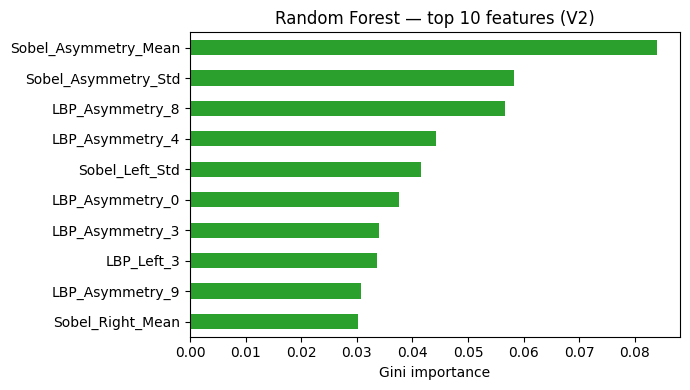


Literature reference (Chan & Zeng, 2018): 85.8% accuracy


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_confusion(axes[0], y_test, y_pred_svm, "SVM (RBF) — confusion matrix (V2)", "Blues")
plot_confusion(axes[1], y_test, y_pred_rf, "Random Forest — confusion matrix (V2)", "Greens")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6.5, 6.5))
for name, proba, colr in (("SVM (RBF)", y_proba_svm, "tab:blue"), ("Random Forest", y_proba_rf, "tab:green")):
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=colr, lw=2, label=f"{name} (AUC = {roc_auc_score(y_test, proba):.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Random classifier (AUC = 0.500)")
ax.set_xlabel("False positive rate (1 − specificity)"); ax.set_ylabel("True positive rate (sensitivity / recall)")
ax.set_title("ROC curves — SVM vs Random Forest (V2 lung segmentation)"); ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 10 most important features (Random Forest, V2):"); print(importances.head(10).round(4).to_string())
fig, ax = plt.subplots(figsize=(7, 4))
importances.head(10)[::-1].plot(kind="barh", ax=ax, color="tab:green"); ax.set_xlabel("Gini importance"); ax.set_title("Random Forest — top 10 features (V2)")
plt.tight_layout(); plt.show()
print("\nLiterature reference (Chan & Zeng, 2018): 85.8% accuracy")

## 18. Baseline vs New Segmentation
**Version 1** (fixed elliptical ROI + Otsu refinement, original implementation) is re-run here with the *same* feature code, the *same* patient split (Section 13) and the *same* grids, so the two versions differ only in the ROI. Its features are also saved to `data/pneumothorax_500_features_baseline_ellipse.csv`. Baseline models are **retrained**, and the original saved Version 1 models were copied to `models/baseline_elliptical_roi/` before the Version 2 models overwrite `models/*.joblib`.

Version 1 numbers can differ slightly from the ones printed by the original notebook run (kept below as a reference) because the original was executed with a different scikit-learn version, which changes tree construction/random-forest and SVM-probability internals; the versions used for this run are printed in the next cell.

Two baseline evaluations are shown: on the full test set (all 158 test images, as in the original notebook) and on exactly the test images that Version 2 could segment (a like-for-like comparison).

In [28]:
import sklearn, skimage, scipy
print("Versions — numpy", np.__version__, "| opencv", cv2.__version__, "| scikit-image", skimage.__version__, "| scikit-learn", sklearn.__version__, "| scipy", scipy.__version__)
baseline_df = build_feature_df("ellipse_baseline")
baseline_df.to_csv(BASELINE_FEATURE_CSV, index=False)
baseline_df = pd.read_csv(BASELINE_FEATURE_CSV)
assert (baseline_df["Segmentation_Success"] == 1).all() and baseline_df[FEATURE_NAMES].notna().all().all()

b_train = baseline_df[baseline_df["Patient ID"].isin(train_patient_ids)]
b_test_full = baseline_df[baseline_df["Patient ID"].isin(test_patient_ids)]
assert set(b_train["Patient ID"]).isdisjoint(b_test_full["Patient ID"])
b_scaler = StandardScaler().fit(b_train[FEATURE_NAMES])                 # scaler fitted on baseline TRAIN only
Xb_train, Xb_test = b_scaler.transform(b_train[FEATURE_NAMES]), b_scaler.transform(b_test_full[FEATURE_NAMES])
yb_train, yb_test = b_train["Label"].values, b_test_full["Label"].values

b_svm_search, b_rf_search = fit_svm(Xb_train, yb_train), fit_rf(Xb_train, yb_train)
print("V1 best SVM params:", b_svm_search.best_params_, "| V1 best RF params:", b_rf_search.best_params_)
b_svm, b_rf = b_svm_search.best_estimator_, b_rf_search.best_estimator_

same_imgs = b_test_full["Image Index"].isin(test_df["Image Index"]).values      # images that V2 could also segment
rows = []
for model_name, mdl in (("SVM (RBF)", b_svm), ("Random Forest", b_rf)):
    pred, proba = mdl.predict(Xb_test), mdl.predict_proba(Xb_test)[:, 1]
    rows.append({"Version": "V1 elliptical ROI (all %d test images)" % len(yb_test), **evaluate_model(model_name, yb_test, pred, proba, verbose=False)})
    rows.append({"Version": "V1 elliptical ROI (same %d images as V2)" % same_imgs.sum(), **evaluate_model(model_name, yb_test[same_imgs], pred[same_imgs], proba[same_imgs], verbose=False)})
for m in (metrics_svm, metrics_rf):
    rows.append({"Version": "V2 lung segmentation (%d test images)" % len(y_test), **{**m, "Model": m["Model"].split(" — ")[0]}})
comparison = pd.DataFrame(rows)[["Model", "Version", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].sort_values(["Model", "Version"], ascending=[False, True]).reset_index(drop=True)
display(comparison.round(4))

# Reference: numbers printed by the ORIGINAL notebook run (sklearn 1.9 on the author's machine) before this modification
original_run = pd.DataFrame([
    {"Model": "SVM (RBF)", "Version": "V1 original saved run (reference)", "Accuracy": 0.6519, "Precision": 0.6526, "Recall": 0.7381, "F1": 0.6927, "ROC-AUC": 0.6613},
    {"Model": "Random Forest", "Version": "V1 original saved run (reference)", "Accuracy": 0.7152, "Precision": 0.7349, "Recall": 0.7262, "F1": 0.7305, "ROC-AUC": 0.7449}])
display(original_run)

Versions — numpy 2.2.3 | opencv 5.0.0 | scikit-image 0.26.0 | scikit-learn 1.9.0 | scipy 1.18.1


c:\Users\Ishit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


V1 best SVM params: {'C': 0.5, 'gamma': 0.1, 'kernel': 'rbf'} | V1 best RF params: {'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 100}


,Model,Version,Accuracy,Precision,Recall,F1,ROC-AUC
0,SVM (RBF),V1 elliptical ROI (all 158 test images),0.6519,0.6526,0.7381,0.6927,0.6613
1,SVM (RBF),V1 elliptical ROI (same 141 images as V2),0.6950,0.7215,0.7308,0.7261,0.7126
2,SVM (RBF),V2 lung segmentation (141 test images),0.7234,0.8000,0.6667,0.7273,0.7582
3,Random Forest,V1 elliptical ROI (all 158 test images),0.7152,0.7349,0.7262,0.7305,0.7449
4,Random Forest,V1 elliptical ROI (same 141 images as V2),0.7376,0.7887,0.7179,0.7517,0.7682
5,Random Forest,V2 lung segmentation (141 test images),0.6950,0.7465,0.6795,0.7114,0.7786


,Model,Version,Accuracy,Precision,Recall,F1,ROC-AUC
0,SVM (RBF),V1 original saved run (reference),0.6519,0.6526,0.7381,0.6927,0.6613
1,Random Forest,V1 original saved run (reference),0.7152,0.7349,0.7262,0.7305,0.7449


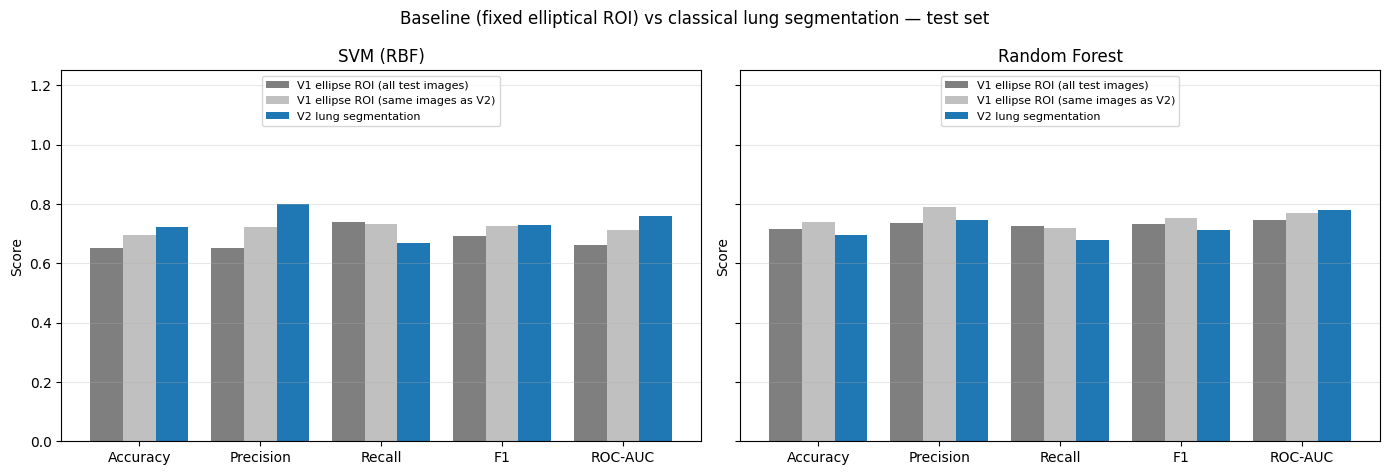

In [29]:
metric_names = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for a, model_name in zip(axes, ["SVM (RBF)", "Random Forest"]):
    sub = comparison[comparison["Model"] == model_name].set_index("Version")
    v1 = sub[sub.index.str.contains("all")].iloc[0][metric_names].astype(float); v1s = sub[sub.index.str.contains("same")].iloc[0][metric_names].astype(float)
    v2 = sub[sub.index.str.startswith("V2")].iloc[0][metric_names].astype(float)
    x = np.arange(len(metric_names)); w = 0.27
    a.bar(x - w, v1.values, w, label="V1 ellipse ROI (all test images)", color="tab:gray")
    a.bar(x, v1s.values, w, label="V1 ellipse ROI (same images as V2)", color="silver")
    a.bar(x + w, v2.values, w, label="V2 lung segmentation", color="tab:blue")
    a.set_xticks(x); a.set_xticklabels(metric_names); a.set_ylim(0, 1.25); a.set_title(model_name); a.set_ylabel("Score"); a.grid(axis="y", alpha=0.3)
    a.legend(loc="upper center", fontsize=8)
plt.suptitle("Baseline (fixed elliptical ROI) vs classical lung segmentation — test set"); plt.tight_layout(); plt.show()

## 19. Conclusions
The statements below are generated from the measured results of this run (nothing is claimed that the numbers do not show).

In [30]:
def _get(model, version_prefix, metric):
    s = comparison[(comparison["Model"] == model) & (comparison["Version"].str.startswith(version_prefix))]
    return float(s[metric].iloc[0])

n_ok, n_all = int(feature_df["Segmentation_Success"].sum()), len(feature_df)
print(f"Lung segmentation succeeded on {n_ok}/{n_all} images ({n_ok / n_all:.1%}); {n_all - n_ok} failures are recorded in the CSV, excluded from ML and listed in Section 11.1.")
for model_name in ("SVM (RBF)", "Random Forest"):
    for metric in ("Accuracy", "ROC-AUC"):
        v1 = _get(model_name, "V1 elliptical ROI (same", metric); v2 = _get(model_name, "V2", metric)
        verdict = "improved" if v2 > v1 + 1e-9 else ("did not change" if abs(v2 - v1) < 1e-9 else "did NOT improve (lower)")
        print(f"{model_name:<14} {metric:<9}: V1 {v1:.4f} -> V2 {v2:.4f}  => segmentation {verdict}")
print("Literature reference (Chan & Zeng 2018): 85.8% accuracy; neither version reaches it.")

Lung segmentation succeeded on 461/500 images (92.2%); 39 failures are recorded in the CSV, excluded from ML and listed in Section 11.1.
SVM (RBF)      Accuracy : V1 0.6950 -> V2 0.7234  => segmentation improved
SVM (RBF)      ROC-AUC  : V1 0.7126 -> V2 0.7582  => segmentation improved
Random Forest  Accuracy : V1 0.7376 -> V2 0.6950  => segmentation did NOT improve (lower)
Random Forest  ROC-AUC  : V1 0.7682 -> V2 0.7786  => segmentation improved
Literature reference (Chan & Zeng 2018): 85.8% accuracy; neither version reaches it.


**Limitations and notes**

* The segmentation is fully classical (Otsu, morphology, connected components, anatomical constraints) and therefore not perfect: masks were inspected visually on samples (Section 5.1); some accepted masks still contain small parts of the shoulder/axilla, and low-contrast or unusual images fail and are reported instead of being silently accepted.
* In the fixed 24-image random sample of Section 5.1, 22 accepted masks follow the lung fields well; 2 (`00001951_007`: right mask on the arm/chest wall, `00016051_022`: right mask reaches into the neck/mediastinum) are visibly wrong, and several masks are slightly smaller or larger than the true lung. The automatic status check cannot catch every such case, so ~5–10 % of the *accepted* masks should be assumed imperfect.
* Only 5 dual-label patients exist; with a 158-image test set (fewer after failures) the metrics carry wide confidence intervals — small differences between Version 1 and Version 2 are within noise.
* The feature set is the original 36-dimensional LBP/Sobel/asymmetry design; no new feature types were added. GLCM features from the implementation plan are still future work.
* "Left/right" are image sides (patient's right/left), consistently in both versions.

## 20. Save Trained Models (Version 2)
The scaler, both classifiers and the feature-column list (retrained on the Version 2 features) are saved with joblib. The Version 1 models remain in `models/baseline_elliptical_roi/`; **do not** score Version 2 features with them (or vice-versa).

In [31]:
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(scaler, f"{MODEL_DIR}/scaler.joblib")
joblib.dump(best_svm, f"{MODEL_DIR}/svm_model.joblib")
joblib.dump(best_rf, f"{MODEL_DIR}/rf_model.joblib")
joblib.dump(feature_cols, f"{MODEL_DIR}/feature_cols.joblib")

# verify the stored artifacts match the newly trained models and the CSV columns
chk_cols = joblib.load(f"{MODEL_DIR}/feature_cols.joblib")
chk_scaler, chk_svm, chk_rf = (joblib.load(f"{MODEL_DIR}/{n}.joblib") for n in ("scaler", "svm_model", "rf_model"))
assert chk_cols == feature_cols == [c for c in pd.read_csv(FEATURE_CSV).columns if c not in metadata_cols]
assert chk_scaler.n_features_in_ == chk_svm.n_features_in_ == chk_rf.n_features_in_ == len(chk_cols)
assert (chk_svm.predict(chk_scaler.transform(test_df[chk_cols])) == y_pred_svm).all()
assert (chk_rf.predict(chk_scaler.transform(test_df[chk_cols])) == y_pred_rf).all()
print("Saved and verified in", MODEL_DIR, ": scaler.joblib, svm_model.joblib, rf_model.joblib, feature_cols.joblib (%d features)" % len(chk_cols))

Saved and verified in ../models/v2 : scaler.joblib, svm_model.joblib, rf_model.joblib, feature_cols.joblib (36 features)


**To reload and reuse later (no retraining):**
```python
import joblib
scaler = joblib.load("../models/scaler.joblib")
best_rf = joblib.load("../models/rf_model.joblib")
feature_cols = joblib.load("../models/feature_cols.joblib")

# new_feature_df: features produced by extract_all_features(..., "segmentation"), same columns as feature_cols
X_new = scaler.transform(new_feature_df[feature_cols])
predictions = best_rf.predict(X_new)
```